<style>
.jp-RenderedHTMLCommon table, .dataframe {font-size: 0.95em;}
.jp-RenderedHTMLCommon h1 {border-bottom: 3px solid #1f5f99; padding-bottom: 6px;}
.jp-RenderedHTMLCommon h2 {border-bottom: 1px solid #9fb9d1; padding-bottom: 4px;}
</style>

# Chapter 4 Interactive Instructor Notebook: Vector Spaces

**Course:** MATH 3260 — Linear Algebra  
**Sections:** 4.1–4.8  
**Audience:** Instructor version

This notebook develops vector spaces from concrete vector arithmetic through subspaces, span, linear independence, basis, dimension, rank, coordinates, and applications. It includes detailed hand calculations, computational verification, classroom questions, and individual instructor answer reveals.

> **Design rule:** establish the mathematical structure first; use Python to verify, visualize, or extend the reasoning rather than replace it.

> **How to Use This Notebook in Class**
>
> Run the notebook from top to bottom before class. Pause at each **Classroom Question**, **Classroom Check**, or section worksheet and give students time to work before clicking **Reveal answer**.
>
> Click the same button again to hide the answer. Complete solutions are stored in a hidden instructor answer bank rather than printed openly in the scrolling notebook.
>
> Display mathematics uses ordinary Markdown/LaTeX rather than raw HTML callout containers so equations render more reliably in JupyterLab, classic Jupyter Notebook, VS Code, and Colab.

## Chapter map

1. **Section 4.1:** Vectors in $\mathbb{R}^n$  
2. **Section 4.2:** Vector Spaces  
3. **Section 4.3:** Subspaces of Vector Spaces  
4. **Section 4.4:** Spanning Sets and Linear Independence  
5. **Section 4.5:** Basis and Dimension  
6. **Section 4.6:** Rank of a Matrix and Systems of Linear Equations  
7. **Section 4.7:** Coordinates and Change of Basis  
8. **Section 4.8:** Applications of Vector Spaces  

Each section ends with a terminology table and an in-class worksheet. Instructor solutions remain hidden until you click the corresponding reveal button.

In [1]:
# Local environment check, imports, classroom reveal helper, and Chapter 4 utilities.
import sys, platform, importlib.util
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math, Markdown, HTML

required_packages = ["numpy", "sympy", "matplotlib"]
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]
if missing_packages:
    raise ModuleNotFoundError(
        "Missing packages: " + ", ".join(missing_packages) +
        ". Install them before running this notebook."
    )

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is unavailable. A dependency-free HTML reveal button will be used instead.")

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)


def reveal_answer(answer_markdown, button_text="Reveal answer"):
    """Create a click-to-reveal / click-to-hide answer button."""
    if not WIDGETS_AVAILABLE:
        import uuid
        try:
            import mistune
            answer_html = mistune.html(answer_markdown)
        except Exception:
            import html as _html
            answer_html = "<pre>" + _html.escape(answer_markdown) + "</pre>"
        box_id = "answer_" + uuid.uuid4().hex
        btn_id = "button_" + uuid.uuid4().hex
        safe_label = button_text.replace('"', '&quot;')
        html_block = f"""
        <div style='margin:8px 0 14px 0;'>
          <button id='{btn_id}'
            style='padding:6px 12px;border:1px solid #4b87b9;border-radius:5px;background:#eef6ff;cursor:pointer;font-weight:600;'
            onclick="var box=document.getElementById('{box_id}'); var btn=document.getElementById('{btn_id}');
                     if(box.style.display==='none'){{box.style.display='block';btn.innerText='Hide answer';
                     if(window.MathJax && MathJax.typesetPromise){{MathJax.typesetPromise([box]);}}}}
                     else{{box.style.display='none';btn.innerText='{safe_label}';}}">
            {safe_label}
          </button>
          <div id='{box_id}' style='display:none;margin-top:10px;padding:10px 12px;border-left:4px solid #4b87b9;background:#fafcff;'>
            {answer_html}
          </div>
        </div>
        """
        display(HTML(html_block))
        return None

    button = widgets.ToggleButton(
        value=False,
        description=button_text,
        icon="eye",
        button_style="info",
        layout=widgets.Layout(width="190px")
    )
    out = widgets.Output()

    def _toggle(change):
        out.clear_output(wait=True)
        if change["new"]:
            button.description = "Hide answer"
            button.icon = "eye-slash"
            with out:
                display(Markdown(answer_markdown))
        else:
            button.description = button_text
            button.icon = "eye"

    button.observe(_toggle, names="value")
    display(widgets.VBox([button, out]))
    return button


def reveal_answer_key(key, button_text="Reveal answer"):
    """Reveal an answer stored in CH4_ANSWERS without exposing it in the classroom cell."""
    return reveal_answer(CH4_ANSWERS[key], button_text=button_text)


def show_matrix(M, label=None):
    M = sp.Matrix(M)
    if label:
        display(Math(rf"{label}={sp.latex(M)}"))
    else:
        display(M)
    return M


def show_vector(v, label=None):
    v = sp.Matrix(v)
    if label:
        display(Math(rf"{label}={sp.latex(v)}"))
    else:
        display(v)
    return v


def show_rref(A, label='A'):
    A = sp.Matrix(A)
    R, pivots = A.rref()
    display(Math(rf"{label}={sp.latex(A)}"))
    display(Math(rf"\operatorname{{rref}}({label})={sp.latex(R)}"))
    print('Pivot-column indices (0-based Python):', pivots)
    print('Mathematical pivot columns (1-based):', tuple(j+1 for j in pivots))
    return R, pivots


def plot_vector2(v, label='v', origin=(0,0), ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
    ox, oy = origin
    vx, vy = float(v[0]), float(v[1])
    ax.quiver(ox, oy, vx, vy, angles='xy', scale_units='xy', scale=1)
    ax.text(ox+vx, oy+vy, f'  {label}')
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.grid(alpha=0.3)
    return ax


def row_reduce_with_steps(M, operations, labels=None):
    """Apply explicit row operations to a SymPy matrix and display every step."""
    M = sp.Matrix(M)
    display(Math(rf"M_0={sp.latex(M)}"))
    for k, op in enumerate(operations, start=1):
        op(M)
        text = labels[k-1] if labels else f'Step {k}'
        display(Markdown(f'**{text}**'))
        display(Math(rf"M_{k}={sp.latex(M)}"))
    return M


def coordinate_vector(B, x):
    Bm = sp.Matrix.hstack(*[sp.Matrix(v) for v in B])
    return Bm.LUsolve(sp.Matrix(x))

In [2]:
CH4_ANSWERS = {'4.1-1': 'Compute componentwise:\n\n$$\n\\mathbf u+\\mathbf v=(5,-2)+(-3,7)=(2,5).\n$$\n\n$$\n2\\mathbf u-\\mathbf v=(10,-4)-(-3,7)=(13,-11).\n$$\n\n$$\n-\\frac12\\mathbf v=-\\frac12(-3,7)=\\left(\\frac32,-\\frac72\\right).\n$$', '4.1-2': 'Compute each scaled vector first:\n\n$$\n3\\mathbf a=(6,3,-3),\n$$\n\n$$\n-2\\mathbf b=(0,-6,-4),\n$$\n\nand\n\n$$\n\\mathbf c=(1,-2,4).\n$$\n\nTherefore,\n\n$$\n3\\mathbf a-2\\mathbf b+\\mathbf c=(7,-5,-3).\n$$', '4.1-3': 'Start with\n\n$$\n2(\\mathbf x-\\mathbf u)=\\mathbf v+\\mathbf x.\n$$\n\nExpand and collect the unknown vector:\n\n$$\n2\\mathbf x-2\\mathbf u=\\mathbf v+\\mathbf x,\n$$\n\nso\n\n$$\n\\mathbf x=2\\mathbf u+\\mathbf v.\n$$\n\nWith $\\mathbf u=(1,2,3)$ and $\\mathbf v=(4,-1,2)$,\n\n$$\n\\boxed{\\mathbf x=(6,3,8)}.\n$$', '4.1-4': 'The equation\n\n$$\n(9,21)=c_1(1,1)+c_2(1,-1)\n$$\n\ngives\n\n$$\nc_1+c_2=9,\n$$\n\nand\n\n$$\nc_1-c_2=21.\n$$\n\nAdding gives $2c_1=30$, so $c_1=15$. Then $c_2=-6$. Hence\n\n$$\n\\boxed{(9,21)=15(1,1)-6(1,-1)}.\n$$', '4.1-5': 'Add the three displacement vectors:\n\n$$\n(2,1)+(-1,3)+(0,-2)=(1,2).\n$$\n\nThus the total displacement is\n\n$$\n\\boxed{(1,2)\\text{ meters}}.\n$$\n\nWith the stated coordinate convention, the player finishes $1$ meter in the positive first-coordinate direction and $2$ meters in the positive second-coordinate direction from the starting position.', '4.2-1': 'Yes. Let\n\n$$\nW=\\{(x,y,z):x+y-z=0\\}.\n$$\n\nThe zero vector belongs to $W$. If $\\mathbf u,\\mathbf v\\in W$ and $a,b\\in\\mathbb R$, then the linear expression $x+y-z$ evaluated at $a\\mathbf u+b\\mathbf v$ equals $a(0)+b(0)=0$. Thus $W$ is closed under linear combinations and is a vector space (indeed a subspace of $\\mathbb R^3$).', '4.2-2': 'No. The zero vector does not satisfy the condition:\n\n$$\n0+0\\ne1.\n$$\n\nA vector space must contain its zero vector, so this set fails immediately.', '4.2-3': 'Yes. This is $P_3$, the set of all polynomials of degree at most $3$ together with the zero polynomial. Sums and scalar multiples remain in $P_3$, and the remaining vector-space axioms follow from the usual polynomial operations.', '4.2-4': 'No. The zero matrix has determinant $0$, not $1$, so it is not in the set. The set also fails scalar closure: if $A$ is $2\\times2$ with $\\det(A)=1$, then\n\n$$\n\\det(2A)=2^2\\det(A)=4,\n$$\n\nso $2A$ is not in the set.', '4.2-5': 'Yes. Let\n\n$$\nW=\\{f\\in C(\\mathbb R):f(0)=0\\}.\n$$\n\nIf $f(0)=g(0)=0$, then\n\n$$\n(f+g)(0)=f(0)+g(0)=0.\n$$\n\nFor any scalar $c$,\n\n$$\n(cf)(0)=c f(0)=0.\n$$\n\nThe zero function belongs to $W$, so $W$ is a vector space under the usual function operations.', '4.2-6': 'The axioms are universal statements: they must hold for **every** permitted vector and scalar. Checking several numerical examples can show that an identity works in those examples, but it cannot establish the universal statement. To prove an axiom, use arbitrary vectors/scalars. To disprove an axiom, one valid counterexample is enough.', '4.3-1': 'Yes. The equation\n\n$$\n2x-y+3z=0\n$$\n\nis homogeneous. The zero vector satisfies it, and linear combinations of solutions remain solutions. Therefore the set is a subspace of $\\mathbb R^3$.', '4.3-2': 'No. The zero vector gives\n\n$$\n2(0)-0+3(0)=0\\ne7.\n$$\n\nSince a subspace must contain the zero vector, the set is not a subspace.', '4.3-3': 'Yes. If $p(0)=p(1)=0$ and $q(0)=q(1)=0$, then\n\n$$\n(p+q)(0)=0,\\; (p+q)(1)=0,\n$$\n\nand for any scalar $c$,\n\n$$\n(cp)(0)=0,\\; (cp)(1)=0.\n$$\n\nThus the set is closed under addition and scalar multiplication and is a subspace of $P_3$.', '4.3-4': 'Yes. The zero matrix is symmetric. If $A^T=A$ and $B^T=B$, then\n\n$$\n(A+B)^T=A^T+B^T=A+B.\n$$\n\nFor any scalar $c$,\n\n$$\n(cA)^T=cA^T=cA.\n$$\n\nTherefore the symmetric $2\\times2$ matrices form a subspace of $M_{2,2}$.', '4.3-5': 'No. The zero matrix is not invertible, so the set fails the zero-vector requirement. It also fails closure under addition; for example,\n\n$$\nI_2+(-I_2)=0,\n$$\n\nalthough both $I_2$ and $-I_2$ are invertible.', '4.3-6': 'From\n\n$$\nx+y-z=0,\n$$\n\nwe obtain\n\n$$\nz=x+y.\n$$\n\nLet $x=s$ and $y=t$. Then\n\n$$\n(x,y,z)=(s,t,s+t)\n=s(1,0,1)+t(0,1,1).\n$$\n\nHence\n\n$$\n\\boxed{W=\\operatorname{span}\\{(1,0,1),(0,1,1)\\}}.\n$$', '4.4-1': 'Put the three vectors into the columns of a matrix and solve\n\n$$\n\\begin{bmatrix}\n1&0&2\\\\\n2&1&0\\\\\n0&1&1\n\\end{bmatrix}\n\\begin{bmatrix}c_1\\\\c_2\\\\c_3\\end{bmatrix}\n=\n\\begin{bmatrix}8\\\\1\\\\7\\end{bmatrix}.\n$$\n\nThe solution is\n\n$$\nc_1=-\\frac45,\\; c_2=\\frac{13}{5},\\; c_3=\\frac{22}{5}.\n$$\n\nTherefore $(8,1,7)$ is a linear combination of the three vectors.', '4.4-2': 'Let\n\n$$\n\\mathbf v_1=(1,0,1),\\; \\mathbf v_2=(0,1,1),\\; \\mathbf v_3=(1,1,2).\n$$\n\nSince\n\n$$\n\\mathbf v_3=\\mathbf v_1+\\mathbf v_2,\n$$\n\nwe have the nontrivial relation\n\n$$\n\\mathbf v_1+\\mathbf v_2-\\mathbf v_3=\\mathbf0.\n$$\n\nHence the set is **linearly dependent**.', '4.4-3': 'No. Since\n\n$$\n(3,6)=3(1,2),\n$$\n\nboth vectors lie on the same line through the origin. Their span is only\n\n$$\n\\{t(1,2):t\\in\\mathbb R\\},\n$$\n\nnot all of $\\mathbb R^2$.', '4.4-4': 'Let\n\n$$\np_1=1+x,\\; p_2=x+x^2,\\; p_3=1+2x+x^2.\n$$\n\nBecause\n\n$$\np_3=p_1+p_2,\n$$\n\nwe have\n\n$$\np_1+p_2-p_3=0.\n$$\n\nThis is a nontrivial dependence relation, so the set is linearly dependent.', '4.4-5': 'Let\n\n$$\n\\mathbf v_1=(1,0,2),\\; \\mathbf v_2=(0,1,1),\\; \\mathbf v_3=(2,1,5).\n$$\n\nObserve that\n\n$$\n\\mathbf v_3=2\\mathbf v_1+\\mathbf v_2.\n$$\n\nTherefore one nontrivial dependence relation is\n\n$$\n\\boxed{2\\mathbf v_1+\\mathbf v_2-\\mathbf v_3=\\mathbf0}.\n$$', '4.4-6': 'Two nonparallel vectors in $\\mathbb R^2$ provide two distinct directions. Because neither is a scalar multiple of the other, they are linearly independent. Two independent vectors in a two-dimensional space form a basis, so every vector in the plane is a linear combination of them.', '4.5-1': 'Place the vectors as columns:\n\n$$\nA=\\begin{bmatrix}\n1&0&1\\\\\n0&1&1\\\\\n1&1&0\n\\end{bmatrix}.\n$$\n\nIts determinant is\n\n$$\n\\det(A)=-2\\ne0.\n$$\n\nThus the columns are linearly independent and span $\\mathbb R^3$. Therefore the set is a basis for $\\mathbb R^3$.', '4.5-2': 'The third vector satisfies\n\n$$\n(1,3,1)=(1,2,0)+(0,1,1).\n$$\n\nSo it is redundant. The first two vectors are not scalar multiples, hence they are independent. Therefore a basis for the span is\n\n$$\n\\{(1,2,0),(0,1,1)\\},\n$$\n\nand\n\n$$\n\\boxed{\\dim=2}.\n$$', '4.5-3': 'The standard basis for $P_4$ is\n\n$$\n\\boxed{\\{1,x,x^2,x^3,x^4\\}}.\n$$\n\nThere are five basis polynomials, so\n\n$$\n\\boxed{\\dim(P_4)=5}.\n$$', '4.5-4': 'A symmetric $2\\times2$ matrix has the form\n\n$$\n\\begin{bmatrix}a&b\\\\b&d\\end{bmatrix}\n=a\\begin{bmatrix}1&0\\\\0&0\\end{bmatrix}\n+b\\begin{bmatrix}0&1\\\\1&0\\end{bmatrix}\n+d\\begin{bmatrix}0&0\\\\0&1\\end{bmatrix}.\n$$\n\nThus one basis is the three matrices above, and\n\n$$\n\\boxed{\\dim=3}.\n$$', '4.5-5': 'Rewrite a general vector:\n\n$$\n(s+t,s-t,3s)=s(1,1,3)+t(1,-1,0).\n$$\n\nThe two spanning vectors are not scalar multiples, so they are independent. Therefore\n\n$$\n\\boxed{\\{(1,1,3),(1,-1,0)\\}}\n$$\n\nis a basis and\n\n$$\n\\boxed{\\dim(W)=2}.\n$$', '4.5-6': 'Since\n\n$$\n\\dim(P_3)=4,\n$$\n\nno linearly independent set in $P_3$ can contain more than four vectors. Therefore any set of five vectors in $P_3$ must be linearly dependent.', '4.6-1': 'Row reduction gives\n\n$$\n\\operatorname{rref}(B)=\n\\begin{bmatrix}\n1&2&0&1\\\\\n0&0&1&1\\\\\n0&0&0&0\n\\end{bmatrix}.\n$$\n\nThere are two pivot positions, so\n\n$$\n\\boxed{\\operatorname{rank}(B)=2}.\n$$', '4.6-2': 'The nonzero rows of an echelon form form a basis for the row space. Therefore one basis is\n\n$$\n\\boxed{\\{(1,2,0,1),(0,0,1,1)\\}}.\n$$', '4.6-3': 'The pivot positions are in columns $1$ and $3$. For the column space, select those columns from the **original** matrix $B$:\n\n$$\n\\boxed{\n\\left\\{\n\\begin{bmatrix}1\\\\2\\\\-1\\end{bmatrix},\n\\begin{bmatrix}0\\\\1\\\\1\\end{bmatrix}\n\\right\\}\n}.\n$$', '4.6-4': 'From the RREF,\n\n$$\nx_1+2x_2+x_4=0,\n$$\n\nand\n\n$$\nx_3+x_4=0.\n$$\n\nLet $x_2=s$ and $x_4=t$. Then\n\n$$\nx_1=-2s-t,\\; x_3=-t.\n$$\n\nHence\n\n$$\n\\mathbf x=s\\begin{bmatrix}-2\\\\1\\\\0\\\\0\\end{bmatrix}\n+t\\begin{bmatrix}-1\\\\0\\\\-1\\\\1\\end{bmatrix}.\n$$\n\nA nullspace basis is given by those two vectors, so\n\n$$\n\\boxed{\\operatorname{nullity}(B)=2}.\n$$', '4.6-5': 'The matrix has $4$ columns. Rank-nullity gives\n\n$$\n4=\\operatorname{rank}(B)+\\operatorname{nullity}(B)=2+2.\n$$\n\nSo the theorem is verified.', '4.6-6': 'First compute\n\n$$\n\\mathbf b=B\\mathbf x_p\n=\\begin{bmatrix}0\\\\1\\\\1\\end{bmatrix}.\n$$\n\nEvery solution is a particular solution plus a nullspace vector:\n\n$$\n\\boxed{\n\\mathbf{x}=\n\\begin{bmatrix}1\\\\0\\\\2\\\\-1\\end{bmatrix}\n+s\\begin{bmatrix}-2\\\\1\\\\0\\\\0\\end{bmatrix}\n+t\\begin{bmatrix}-1\\\\0\\\\-1\\\\1\\end{bmatrix}\n}.\n$$', '4.7-1': 'Solve\n\n$$\nc_1(1,2)+c_2(2,-1)=(8,7).\n$$\n\nThis gives\n\n$$\nc_1+2c_2=8,\n$$\n\nand\n\n$$\n2c_1-c_2=7.\n$$\n\nThe solution is\n\n$$\nc_1=\\frac{22}{5},\\; c_2=\\frac95.\n$$\n\nThus\n\n$$\n\\boxed{[(8,7)]_B=\\begin{bmatrix}22/5\\\\9/5\\end{bmatrix}}.\n$$', '4.7-2': 'Use the coordinates as coefficients of the ordered basis vectors:\n\n$$\n\\mathbf x=3(1,2)-2(2,-1).\n$$\n\nTherefore,\n\n$$\n\\boxed{\\mathbf x=(-1,8)}.\n$$', '4.7-3': 'The columns of $P_{S\\leftarrow B}$ are the standard-coordinate vectors of the basis $B$:\n\n$$\nP_{S\\leftarrow B}=\\begin{bmatrix}1&1\\\\1&-1\\end{bmatrix}.\n$$\n\nThe reverse transition matrix is its inverse:\n\n$$\nP_{B\\leftarrow S}\n=\\frac12\\begin{bmatrix}1&1\\\\1&-1\\end{bmatrix}.\n$$', '4.7-4': 'Use\n\n$$\n[\\mathbf x]_S=P_{S\\leftarrow B}[\\mathbf x]_B.\n$$\n\nThen\n\n$$\n\\begin{bmatrix}1&1\\\\1&-1\\end{bmatrix}\n\\begin{bmatrix}5\\\\4\\end{bmatrix}\n=\n\\begin{bmatrix}9\\\\1\\end{bmatrix}.\n$$\n\nThus the standard coordinates are\n\n$$\n\\boxed{(9,1)}.\n$$', '4.7-5': 'Relative to the ordered basis $\\{1,x,x^2\\}$, the coefficients are read directly from\n\n$$\np(x)=3-2x+4x^2.\n$$\n\nHence\n\n$$\n\\boxed{[p]_B=\\begin{bmatrix}3\\\\-2\\\\4\\end{bmatrix}}.\n$$', '4.7-6': 'Let $t=x-1$, so $x=t+1$. Then\n\n$$\n3-2(t+1)+4(t+1)^2=5+6t+4t^2.\n$$\n\nTherefore\n\n$$\np(x)=5+6(x-1)+4(x-1)^2,\n$$\n\nso\n\n$$\n\\boxed{[p]_B=\\begin{bmatrix}5\\\\6\\\\4\\end{bmatrix}}.\n$$', '4.8-1': "For $y=\\cos x$,\n\n$$\ny''=-\\cos x,\n$$\n\nso\n\n$$\ny''+y=-\\cos x+\\cos x=0.\n$$\n\nFor $y=\\sin x$,\n\n$$\ny''=-\\sin x,\n$$\n\nso\n\n$$\ny''+y=-\\sin x+\\sin x=0.\n$$\n\nThus both are solutions.", '4.8-2': 'The Wronskian is\n\n$$\nW(\\cos x,\\sin x)\n=\\det\\begin{bmatrix}\n\\cos x&\\sin x\\\\\n-\\sin x&\\cos x\n\\end{bmatrix}.\n$$\n\nTherefore,\n\n$$\nW=\\cos^2x+\\sin^2x=1.\n$$\n\nSince the Wronskian is nonzero, the two functions are linearly independent.', '4.8-3': 'For $1,x,x^2$,\n\n$$\nW=\n\\det\\begin{bmatrix}\n1&x&x^2\\\\\n0&1&2x\\\\\n0&0&2\n\\end{bmatrix}.\n$$\n\nThe matrix is triangular, so\n\n$$\n\\boxed{W=1(1)(2)=2}.\n$$', '4.8-4': 'Compare with the standard ellipse form:\n\n$$\n\\frac{(x-h)^2}{a^2}+\\frac{(y-k)^2}{b^2}=1.\n$$\n\nThus the center is\n\n$$\n\\boxed{(3,-1)},\n$$\n\nand the semiaxis lengths are\n\n$$\n\\boxed{4\\text{ and }3}.\n$$', '4.8-5': 'Compare with\n\n$$\n(y-k)^2=4p(x-h).\n$$\n\nHere $h=-1$, $k=2$, and $4p=-12$, so $p=-3$. Therefore the vertex is\n\n$$\n\\boxed{(-1,2)},\n$$\n\nand because $p<0$, the parabola opens to the left.', '4.8-6': "Use the supplied $45^\\circ$ rotation\n\n$$\nx=\\frac{x'-y'}{\\sqrt2},\n$$\n\nand\n\n$$\ny=\\frac{x'+y'}{\\sqrt2}.\n$$\n\nSubstituting into\n\n$$\n4x^2+4xy+4y^2=12\n$$\n\nand simplifying gives\n\n$$\n6x'^2+2y'^2=12.\n$$\n\nDivide by $12$:\n\n$$\n\\boxed{\\frac{x'^2}{2}+\\frac{y'^2}{6}=1}.\n$$\n\nTherefore the rotated conic is an ellipse. The systematic method for discovering the principal directions is developed later in the course.", 'concept-4.1-components': 'Vector addition is componentwise because each coordinate records displacement along one coordinate direction. Thus $(u_1,u_2)+(v_1,v_2)=(u_1+v_1,u_2+v_2)$. The vector magnitude is a separate scalar quantity and is not added componentwise.', 'concept-4.1-lc': 'The unknowns are the **coefficients** $c_1,c_2,c_3$, not the vector components of the given vectors. Writing the vectors as columns converts the linear-combination question into a system $A\\mathbf c=\\mathbf x$.', 'concept-4.2-disproof': 'One failed axiom is enough to prove that a set is not a vector space. The fastest checks are often: does it contain the zero vector, is it closed under addition, and is it closed under scalar multiplication?', 'concept-4.2-unusual-zero': 'The zero vector is defined by the addition operation. Here $u\\oplus z=u$ requires $u+z-1=u$, so $z=1$. Thus the zero vector for these unusual operations is $1$, not the ordinary real number $0$ viewed under usual addition.', 'concept-4.3-homogeneous': 'A homogeneous linear constraint has right-hand side $0$. Linear combinations preserve that zero: if $L(\\mathbf u)=0$ and $L(\\mathbf v)=0$, then $L(a\\mathbf u+b\\mathbf v)=aL(\\mathbf u)+bL(\\mathbf v)=0$. That is why homogeneous solution sets naturally form subspaces.', 'concept-4.3-zero-not-enough': 'Containing the zero vector is necessary but not sufficient. A set can contain zero and still fail closure. For example, the union of the $x$- and $y$-axes contains $(0,0)$, but $(1,0)+(0,1)=(1,1)$ is not in the union.', 'concept-4.4-span-vs-ind': '**Span** asks whether the vectors provide enough directions to generate the target space. **Independence** asks whether any vector is redundant. A set may span but be dependent (too many vectors), or be independent but fail to span (too few vectors). A basis requires both properties.', 'concept-4.4-det': 'For three vectors in $\\mathbb R^3$, putting them into the columns of a $3\\times3$ matrix gives a useful test: nonzero determinant means the matrix is invertible, so the columns are independent and span $\\mathbb R^3$.', 'concept-4.5-basis': 'A basis must satisfy **both** conditions: it spans the space and is linearly independent. Spanning prevents missing directions; independence prevents redundant directions. That is why basis coordinates are unique.', 'concept-4.5-dimension': 'If $\\dim(V)=n$, every basis has exactly $n$ vectors. Therefore more than $n$ vectors must be dependent, while fewer than $n$ vectors cannot span the whole space.', 'concept-4.6-row-col': 'Elementary row operations preserve the row space, so the nonzero rows of an echelon form can be used directly for a row-space basis. Row operations generally change the actual column vectors and therefore change the column space. We use pivot locations from the RREF, but select the corresponding columns from the original matrix.', 'concept-4.6-consistency': 'The equation $A\\mathbf x=\\mathbf b$ says exactly that $\\mathbf b$ is a linear combination of the columns of $A$, with the entries of $\\mathbf x$ as coefficients. Therefore the system is consistent precisely when $\\mathbf b\\in\\operatorname{Col}(A)$.', 'concept-4.6-rank-nullity': 'Rank counts the number of pivot variables/output directions. Nullity counts the number of free-variable directions in the nullspace. With $n$ input coordinates, every column corresponds either to a pivot variable or contributes a free-variable direction, giving $n=\\operatorname{rank}(A)+\\operatorname{nullity}(A)$.', 'concept-4.7-vector-coordinates': 'The geometric/algebraic vector $\\mathbf x$ is unchanged; only its coordinate list changes with the basis. The coordinate vector $[\\mathbf x]_B$ records the coefficients needed to reconstruct $\\mathbf x$ from the ordered basis $B$.', 'concept-4.7-direction': 'The arrow in $P_{C\\leftarrow B}$ reads “from $B$-coordinates to $C$-coordinates.” Thus $[\\mathbf x]_C=P_{C\\leftarrow B}[\\mathbf x]_B$. Reversing the direction requires the inverse transition matrix.', 'concept-4.8-wronskian': 'A nonzero Wronskian at some point guarantees linear independence. For solutions of the same linear homogeneous ODE under the usual continuity assumptions, the Wronskian is either identically zero or never zero on the interval, so the Wronskian test is especially clean.', 'concept-4.8-rotation': "After substituting the supplied $45^\\circ$ rotation, the two mixed $x'y'$ contributions cancel. The resulting equation contains only $x'^2$ and $y'^2$, so the new coordinate axes are aligned with the ellipse's principal directions. Later in the course, eigenvectors will give a systematic method for finding such directions."}

> **Notebook Workflow**
>
> The mathematical explanation comes first. Python cells are optional verification or visualization. Classroom questions and worksheets are followed by individual answer buttons so solutions remain hidden until you choose to reveal them.

> **Example Policy**
>
> Numerical and application examples are teaching models. Personal-interest themes are used selectively, but fictional scenarios are identified as such. The purpose is to connect abstract vector-space structure with concrete calculations without replacing the underlying definitions and proofs.

# Section 4.1 - Vectors in $\mathbb{R}^n$

## Learning objectives

Students should be able to:

- represent vectors geometrically as directed line segments;
- add, subtract, and scale vectors in $\mathbb{R}^2$, $\mathbb{R}^3$, and $\mathbb{R}^n$;
- interpret vector operations geometrically;
- use vector algebra properties;
- write one vector as a linear combination of other vectors.

> **Definition: vector in the plane**
>
> A vector $\mathbf{v}=(v_1,v_2)$ can be represented by a directed segment from the origin to $(v_1,v_2)$. The numbers $v_1$ and $v_2$ are its components.

## Original application: hiking displacement

A hiker travels according to two displacement vectors, measured in kilometers:

$$
\mathbf{u}=(4,3), \; \mathbf{v}=(-1,5).
$$

The total displacement is

$$
\mathbf{u}+\mathbf{v}=(4-1,3+5)=(3,8).
$$

The vector $-\mathbf{u}=(-4,-3)$ reverses the first displacement, while $\frac12\mathbf{u}=(2,\frac32)$ has the same direction and half the magnitude.

### Classroom Check: Components or Magnitudes?

Why do we add vectors componentwise rather than adding their lengths?

In [3]:
reveal_answer_key("concept-4.1-components", 'Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

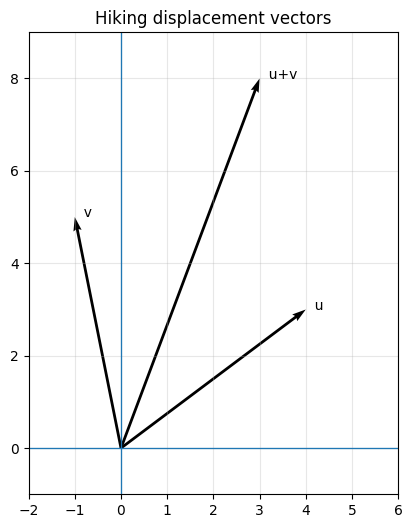

In [4]:
u = np.array([4.,3.])
v = np.array([-1.,5.])
fig, ax = plt.subplots(figsize=(7,6))
plot_vector2(u, 'u', ax=ax)
plot_vector2(v, 'v', ax=ax)
plot_vector2(u+v, 'u+v', ax=ax)
ax.set_xlim(-2,6); ax.set_ylim(-1,9); ax.set_aspect('equal')
ax.set_title('Hiking displacement vectors')
plt.show()

## The parallelogram rule

The vector sum can be visualized as the diagonal of a parallelogram. Equivalently, translate the second vector so that its initial point is the terminal point of the first.

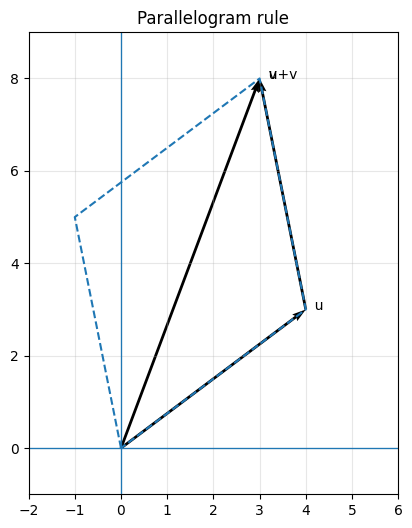

In [5]:
fig, ax = plt.subplots(figsize=(7,6))
plot_vector2(u,'u',ax=ax)
plot_vector2(v,'v',origin=u,ax=ax)
plot_vector2(u+v,'u+v',ax=ax)
ax.plot([0,v[0],u[0]+v[0],u[0],0],[0,v[1],u[1]+v[1],u[1],0],linestyle='--')
ax.set_xlim(-2,6); ax.set_ylim(-1,9); ax.set_aspect('equal'); ax.set_title('Parallelogram rule')
plt.show()

> **Vector operations in $\mathbb{R}^n$**
>
> For $\mathbf{u}=(u_1,\ldots,u_n)$, $\mathbf{v}=(v_1,\ldots,v_n)$, and scalar $c$, define $\mathbf{u}+\mathbf{v}=(u_1+v_1,\ldots,u_n+v_n)$ and $c\mathbf{u}=(cu_1,\ldots,cu_n)$.

## Spurs-inspired vector arithmetic in $\mathbb{R}^3$

Let

$$
\mathbf{a}=(9,1,20), \; \mathbf{b}=(21,-3,4).
$$

Then

$$
\mathbf{a}+\mathbf{b}=(30,-2,24),
$$

$$
2\mathbf{a}=(18,2,40),
$$

and

$$
\mathbf{b}-2\mathbf{a}=(3,-5,-36).
$$

The entries are Spurs-inspired teaching values; they do not represent a single real dataset.

In [6]:
a = sp.Matrix([9,1,20])
b = sp.Matrix([21,-3,4])
show_vector(a+b, r'\mathbf{a}+\mathbf{b}')
show_vector(2*a, r'2\mathbf{a}')
show_vector(b-2*a, r'\mathbf{b}-2\mathbf{a}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡ 3 ⎤
⎢   ⎥
⎢-5 ⎥
⎢   ⎥
⎣-36⎦

## Solving a vector equation in $\mathbb{R}^4$

Let

$$
\mathbf{u}=(2,-1,3,0),\;
\mathbf{v}=(1,4,-2,5),\;
\mathbf{w}=(-1,2,1,-3).
$$

Solve

$$
3(\mathbf{x}+\mathbf{w})=2\mathbf{u}-\mathbf{v}+\mathbf{x}.
$$

Move the $\mathbf{x}$ terms together:

$$
3\mathbf{x}+3\mathbf{w}=2\mathbf{u}-\mathbf{v}+\mathbf{x},
$$

$$
2\mathbf{x}=2\mathbf{u}-\mathbf{v}-3\mathbf{w},
$$

so

$$
\mathbf{x}=\frac12\left(2\mathbf{u}-\mathbf{v}-3\mathbf{w}\right).
$$

Substitution gives

$$
\mathbf{x}=\left(3,-6,\frac52,2\right).
$$

In [7]:
u4=sp.Matrix([2,-1,3,0]); v4=sp.Matrix([1,4,-2,5]); w4=sp.Matrix([-1,2,1,-3])
x4=sp.Rational(1,2)*(2*u4-v4-3*w4)
show_vector(x4, r'\mathbf{x}')
print('Verification:', 3*(x4+w4) == 2*u4-v4+x4)

<IPython.core.display.Math object>

Verification: True


> **Definition: linear combination**
>
> A vector $\mathbf{x}$ is a linear combination of $\mathbf{v}_1,\ldots,\mathbf{v}_k$ if $\mathbf{x}=c_1\mathbf{v}_1+\cdots+c_k\mathbf{v}_k$ for scalars $c_1,\ldots,c_k$.

## Detailed linear-combination example

Let

$$
\mathbf{v}_1=(1,2,0),\;
\mathbf{v}_2=(0,1,1),\;
\mathbf{v}_3=(2,0,1),
$$

and let $\mathbf{x}=(7,4,5)$. We seek $c_1,c_2,c_3$ such that

$$
\mathbf{x}=c_1\mathbf{v}_1+c_2\mathbf{v}_2+c_3\mathbf{v}_3.
$$

Equating components gives

$$
\begin{aligned}
c_1+2c_3&=7,\\
2c_1+c_2&=4,\\
c_2+c_3&=5.
\end{aligned}
$$

The augmented matrix is

$$
\left[
\begin{array}{ccc|c}
1&0&2&7\\
2&1&0&4\\
0&1&1&5
\end{array}
\right].
$$

Apply $R_2\leftarrow R_2-2R_1$:

$$
\left[
\begin{array}{ccc|c}
1&0&2&7\\
0&1&-4&-10\\
0&1&1&5
\end{array}
\right].
$$

Then $R_3\leftarrow R_3-R_2$:

$$
\left[
\begin{array}{ccc|c}
1&0&2&7\\
0&1&-4&-10\\
0&0&5&15
\end{array}
\right].
$$

Thus $c_3=3$, $c_2=2$, and $c_1=1$. Therefore,

$$
\boxed{\mathbf{x}=\mathbf{v}_1+2\mathbf{v}_2+3\mathbf{v}_3}.
$$

### Classroom Check: What Are the Unknowns?

In a linear-combination problem such as

$$
\mathbf x=c_1\mathbf v_1+c_2\mathbf v_2+c_3\mathbf v_3,
$$

what quantities are we solving for, and how does this become a matrix equation?

In [8]:
reveal_answer_key("concept-4.1-lc", 'Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

In [9]:
V = sp.Matrix.hstack(sp.Matrix([1,2,0]), sp.Matrix([0,1,1]), sp.Matrix([2,0,1]))
x = sp.Matrix([7,4,5])
show_matrix(V, 'V')
show_vector(V.LUsolve(x), r'\mathbf{c}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡1⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎣3⎦

> **Common mistakes**
>
> Do not confuse a vector with its length. Add vectors componentwise, not by adding lengths. A linear combination problem is a system for unknown coefficients.

> **Closing note**
>
> Vector operations are the computational language of the rest of the chapter. Spanning, independence, basis, coordinates, and rank all ask increasingly structural questions about linear combinations.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Vector | Ordered list of components; geometrically, a directed displacement. |
| Component | One coordinate of a vector. |
| Zero vector | Vector whose components are all zero. |
| Vector addition | Componentwise addition. |
| Scalar multiplication | Multiplication of every component by the same scalar. |
| Additive inverse | $-\mathbf{v}$, satisfying $\mathbf{v}+(-\mathbf{v})=\mathbf{0}$. |
| Linear combination | Sum $c_1\mathbf{v}_1+\cdots+c_k\mathbf{v}_k$. |

## Section 4.1 Worksheet — In-Class Practice

Work each problem before revealing the instructor solution.

### Problem 1

Let $\mathbf{u}=(5,-2)$ and $\mathbf{v}=(-3,7)$. Find $\mathbf{u}+\mathbf{v}$, $2\mathbf{u}-\mathbf{v}$, and $-\frac12\mathbf{v}$.

In [10]:
reveal_answer_key("4.1-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Let $\mathbf{a}=(2,1,-1)$, $\mathbf{b}=(0,3,2)$, and $\mathbf{c}=(1,-2,4)$. Compute $3\mathbf{a}-2\mathbf{b}+\mathbf{c}$.

In [11]:
reveal_answer_key("4.1-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Solve $2(\mathbf{x}-\mathbf{u})=\mathbf{v}+\mathbf{x}$ for $\mathbf{x}$ when $\mathbf{u}=(1,2,3)$ and $\mathbf{v}=(4,-1,2)$.

In [12]:
reveal_answer_key("4.1-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Determine coefficients $c_1,c_2$ such that $(9,21)=c_1(1,1)+c_2(1,-1)$.

In [13]:
reveal_answer_key("4.1-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

A badminton player makes court-movement vectors $(2,1)$, $(-1,3)$, and $(0,-2)$ meters. Find the total displacement and interpret it.

In [14]:
reveal_answer_key("4.1-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

# Section 4.2 - Vector Spaces

## Learning objectives

Students should be able to:

- state and interpret the ten vector-space axioms;
- recognize standard vector spaces such as $\mathbb{R}^n$, $P_n$, $M_{m,n}$, and spaces of functions;
- verify selected axioms for an unfamiliar set and operations;
- disprove vector-space status efficiently by finding one failed axiom.

> **Definition: Vector Space**
>
> A **vector space** is a nonempty set $V$ together with two operations:
>
> - vector addition, which combines two vectors in $V$;
> - scalar multiplication, which multiplies a vector in $V$ by a real scalar.
>
> These operations must satisfy the ten vector-space axioms listed below.
>
> The elements of $V$ do not have to be geometric arrows. They may be vectors in $\mathbb R^n$, matrices, polynomials, functions, or other objects, provided the specified operations satisfy the axioms.

## The Ten Vector-Space Axioms

For all $\mathbf u,\mathbf v,\mathbf w\in V$ and all scalars $c,d\in\mathbb R$:

1. **Closure under addition**

   $$
   \mathbf u+\mathbf v\in V.
   $$

2. **Commutativity of addition**

   $$
   \mathbf u+\mathbf v=\mathbf v+\mathbf u.
   $$

3. **Associativity of addition**

   $$
   (\mathbf u+\mathbf v)+\mathbf w=\mathbf u+(\mathbf v+\mathbf w).
   $$

4. **Additive identity**

   There exists a vector $\mathbf0\in V$ such that

   $$
   \mathbf u+\mathbf0=\mathbf u.
   $$

5. **Additive inverse**

   For every $\mathbf u\in V$, there exists $-\mathbf u\in V$ such that

   $$
   \mathbf u+(-\mathbf u)=\mathbf0.
   $$

6. **Closure under scalar multiplication**

   $$
   c\mathbf u\in V.
   $$

7. **Distributivity over vector addition**

   $$
   c(\mathbf u+\mathbf v)=c\mathbf u+c\mathbf v.
   $$

8. **Distributivity over scalar addition**

   $$
   (c+d)\mathbf u=c\mathbf u+d\mathbf u.
   $$

9. **Associativity of scalar multiplication**

   $$
   c(d\mathbf u)=(cd)\mathbf u.
   $$

10. **Scalar multiplicative identity**

    $$
    1\mathbf u=\mathbf u.
    $$

> **Practical point:** to prove that a familiar set with the usual operations is a vector space, we often inherit many axioms from a known vector space and focus on closure and the zero vector. To prove that a set is **not** a vector space, one failed axiom is enough.

## Important standard vector spaces

- $\mathbb{R}^n$: all real $n$-tuples;
- $P_n$: all polynomials of degree at most $n$, together with the zero polynomial;
- $M_{m,n}$: all $m\times n$ real matrices;
- $C[a,b]$: continuous real-valued functions on $[a,b]$;
- solution sets of homogeneous linear systems.

## Example: $M_{2,3}$ is a vector space

If $A$ and $B$ are $2\times3$ matrices, then $A+B$ is also $2\times3$. If $c$ is a scalar, then $cA$ is also $2\times3$. Thus closure holds. The remaining axioms follow from ordinary real-number arithmetic applied entrywise. The zero vector is the zero matrix and the additive inverse of $A$ is $-A$.

In [15]:
A = sp.Matrix([[1,9,21],[20,4,-3]])
B = sp.Matrix([[2,-1,5],[0,7,1]])
show_matrix(A+B, 'A+B')
show_matrix(-A, '-A')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡-1   -9  -21⎤
⎢            ⎥
⎣-20  -4   3 ⎦

## Example: $P_2$ is a vector space

A polynomial in $P_2$ has the form

$$
p(x)=a_0+a_1x+a_2x^2.
$$

The sum of two such polynomials and any scalar multiple remain of degree at most two. The zero polynomial belongs to $P_2$, and $-p(x)$ is also in $P_2$. Therefore $P_2$ is a vector space under ordinary polynomial operations.

> **Fast disproof strategy**
>
> To show that a set is not a vector space, one counterexample is sufficient. Common targets are failure to contain the zero vector, failure of closure under addition, or failure of closure under multiplication by a negative scalar.

### Classroom Check: Fastest Disproof

To show that a proposed set is **not** a vector space, do we need to check all ten axioms? Which properties are usually the fastest to test?

In [16]:
reveal_answer_key("concept-4.2-disproof", 'Reveal strategy')

ToggleButton(value=False, button_style='info', description='Reveal strategy', icon='eye', layout=Layout(width=…

## Non-example: polynomials of exactly degree two

Let $W$ be the set of all polynomials of exactly degree two. Consider

$$
p(x)=x^2+x, \; q(x)=-x^2+2.
$$

Both are in $W$, but

$$
p(x)+q(x)=x+2,
$$

which has degree one. Thus $W$ is not closed under addition and is not a vector space.

## Non-example: a positivity restriction

Let

$$
W=\{(x,y)\in\mathbb{R}^2:x>0\}.
$$

The vector $(1,0)$ lies in $W$, but

$$
-1(1,0)=(-1,0)\notin W.
$$

So $W$ is not closed under scalar multiplication. It also does not contain the zero vector.

## Optional example: unusual operations

Let $V=\mathbb{R}$ with operations

$$
u\oplus v=u+v-1,
$$

and

$$
c\odot u=cu-c+1.
$$

The zero vector for $\oplus$ is $1$, not $0$, because $u\oplus1=u$. This example illustrates that the axioms concern the specified operations, not necessarily the usual ones.

### Classroom Check: Where Is the Zero Vector?

Under the unusual addition $u\oplus v=u+v-1$, why is the additive identity $1$ rather than $0$?

In [17]:
reveal_answer_key("concept-4.2-unusual-zero", 'Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

In [18]:
def add_star(u,v): return u+v-1
def scale_star(c,u): return c*u-c+1
for u0 in [0,2,5]:
    print(u0, add_star(u0,1), scale_star(1,u0), scale_star(0,u0))

0 0 0 1
2 2 2 1
5 5 5 1


> **Closing note**
>
> A vector space is an algebraic environment in which linear combinations behave predictably. The elements need not be arrows; they may be matrices, polynomials, functions, signals, or data objects.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Vector space | Set with addition and scalar multiplication satisfying ten axioms. |
| Closure | An operation keeps results inside the set. |
| Additive identity | The zero vector of the space. |
| Additive inverse | Vector that sums with a given vector to the zero vector. |
| $P_n$ | Polynomials of degree at most $n$. |
| $M_{m,n}$ | Real $m\times n$ matrices. |
| $C[a,b]$ | Continuous functions on $[a,b]$. |

## Section 4.2 Worksheet — In-Class Practice

Work each problem before revealing the instructor solution.

### Problem 1

All vectors $(x,y,z)$ satisfying $x+y-z=0$. Determine whether this is a vector space under the usual operations and justify.

In [19]:
reveal_answer_key("4.2-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

All vectors $(x,y)$ satisfying $x+y=1$. Determine whether this is a vector space under the usual operations and justify.

In [20]:
reveal_answer_key("4.2-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

All polynomials of degree at most three. Determine whether this is a vector space under the usual operations and justify.

In [21]:
reveal_answer_key("4.2-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

All $2\times2$ matrices with determinant $1$. Determine whether this is a vector space under the usual operations and justify.

In [22]:
reveal_answer_key("4.2-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

All continuous functions $f$ satisfying $f(0)=0$. Determine whether this is a vector space under the usual operations and justify.

In [23]:
reveal_answer_key("4.2-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Explain why testing only several numerical examples cannot prove all ten vector-space axioms.

In [24]:
reveal_answer_key("4.2-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Section 4.3 - Subspaces of Vector Spaces

## Learning objectives

Students should be able to:

- apply the subspace test;
- use the zero-vector test to reject affine sets quickly;
- recognize lines and planes through the origin as subspaces;
- analyze subspaces of $\mathbb{R}^n$, polynomial spaces, and matrix spaces;
- understand intersections of subspaces.

> **Definition: subspace**
>
> A nonempty subset $W$ of a vector space $V$ is a subspace when it is itself a vector space using the same addition and scalar multiplication as $V$.

> **Subspace Test**
>
> Let $W$ be a subset of a known vector space $V$. Then $W$ is a subspace of $V$ if:
>
> 1. $\mathbf0\in W$;
> 2. whenever $\mathbf u,\mathbf v\in W$, we have $\mathbf u+\mathbf v\in W$;
> 3. whenever $\mathbf u\in W$ and $c$ is a scalar, we have $c\mathbf u\in W$.
>
> Equivalently, after confirming that $W$ is nonempty, we can combine the two closure conditions into one statement:
>
> $$
> a\mathbf u+b\mathbf v\in W
> $$
>
> for every $\mathbf u,\mathbf v\in W$ and all scalars $a,b$.
>
> A quick first check is whether the zero vector belongs to $W$. If it does not, then $W$ cannot be a subspace.

## Original example: a plane through the origin

Let

$$
W=\{(x,y,z)\in\mathbb{R}^3:x-2y+z=0\}.
$$

The zero vector belongs to $W$. If $\mathbf{u},\mathbf{v}\in W$, then

$$
u_1-2u_2+u_3=0,
\;
v_1-2v_2+v_3=0.
$$

For scalars $a,b$,

$$
(a\mathbf{u}+b\mathbf{v})_1-2(a\mathbf{u}+b\mathbf{v})_2+(a\mathbf{u}+b\mathbf{v})_3
=a(0)+b(0)=0.
$$

Hence $W$ is a subspace.

Solving for $x$ gives

$$
x=2y-z.
$$

Let $y=s$ and $z=t$. Then

$$
(x,y,z)=s(2,1,0)+t(-1,0,1).
$$

### Classroom Check: Why Does Homogeneous Matter?

Why do equations with right-hand side $0$ naturally produce subspaces?

In [25]:
reveal_answer_key("concept-4.3-homogeneous", 'Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

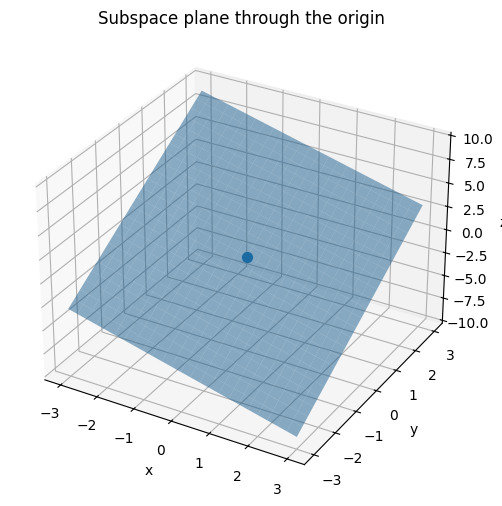

In [26]:
# Plot part of the plane x - 2y + z = 0, or z = -x + 2y.
xx, yy = np.meshgrid(np.linspace(-3,3,25), np.linspace(-3,3,25))
zz = -xx + 2*yy
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx,yy,zz,alpha=0.5)
ax.scatter([0],[0],[0],s=50)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Subspace plane through the origin')
plt.show()

## Non-example: a parallel affine plane

Consider

$$
U=\{(x,y,z):x-2y+z=1\}.
$$

The zero vector does not satisfy the equation. Therefore $U$ is not a subspace. Geometrically, it is parallel to $W$ but shifted away from the origin.

## Affine Sets: Shifted Subspaces

The previous example

$$
U=\{(x,y,z)\in\mathbb{R}^3:x-2y+z=1\}
$$

is not a subspace because it does not contain the zero vector.

However, it still has a very important linear structure. It is an example of an **affine set**.

> **Definition: affine set**
>
> Let $W$ be a subspace of a vector space $V$, and let $\mathbf{v}_0\in V$.
> A set of the form
>
> $$
> \mathbf{v}_0+W
> =
> \{\mathbf{v}_0+\mathbf{w}:\mathbf{w}\in W\}
> $$
>
> is called an **affine set**.
>
> Geometrically, an affine set is a subspace that has been **shifted** or **translated** away from the origin.

The vector $\mathbf{v}_0$ tells us how far the subspace has been shifted.

---

### Returning to the plane example

Recall the subspace

$$
W=
\{(x,y,z)\in\mathbb{R}^3:x-2y+z=0\}.
$$

We previously found

$$
W
=
\{s(2,1,0)+t(-1,0,1):s,t\in\mathbb{R}\}.
$$

Now consider

$$
U=
\{(x,y,z)\in\mathbb{R}^3:x-2y+z=1\}.
$$

We first find one particular point in $U$.

For example,

$$
\mathbf{v}_0=
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
$$

belongs to $U$ because

$$
1-2(0)+0=1.
$$

We claim that

$$
U=\mathbf{v}_0+W.
$$

Therefore,

$$
U
=
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
+
W.
$$

Using the description of $W$,

$$
U
=
\left\{
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
+
s
\begin{bmatrix}
2\\
1\\
0
\end{bmatrix}
+
t
\begin{bmatrix}
-1\\
0\\
1
\end{bmatrix}
:
s,t\in\mathbb{R}
\right\}.
$$

So $U$ has the same directions as the subspace $W$, but the entire plane has been shifted away from the origin.

---

### Why does this work?

Suppose

$$
\mathbf{u}\in U.
$$

Then

$$
u_1-2u_2+u_3=1.
$$

Since

$$
\mathbf{v}_0=
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix},
$$

we have

$$
\mathbf{u}-\mathbf{v}_0
=
\begin{bmatrix}
u_1-1\\
u_2\\
u_3
\end{bmatrix}.
$$

Now check the homogeneous equation:

$$
(u_1-1)-2u_2+u_3
=
(u_1-2u_2+u_3)-1
=
1-1
=
0.
$$

Therefore,

$$
\mathbf{u}-\mathbf{v}_0\in W.
$$

Hence every vector in $U$ can be written as

$$
\mathbf{u}
=
\mathbf{v}_0+\mathbf{w}
$$

for some $\mathbf{w}\in W$.

This is exactly the statement

$$
U=\mathbf{v}_0+W.
$$

---

### Subspace versus affine set

Compare the two planes:

$$
W=\{(x,y,z):x-2y+z=0\},
$$

and

$$
U=\{(x,y,z):x-2y+z=1\}.
$$

The first plane passes through the origin, so it is a subspace.

The second plane is parallel to the first one but shifted away from the origin, so it is affine but not a subspace.

In general,

$$
\boxed{
\text{subspace}
=
\text{linear set through the origin}
}
$$

while

$$
\boxed{
\text{affine set}
=
\text{shifted subspace}
}
$$

An affine set $\mathbf{v}_0+W$ is a subspace only when the shift does not actually move the set away from the origin.

In particular, if

$$
\mathbf{v}_0\in W,
$$

then

$$
\mathbf{v}_0+W=W.
$$

---

### Connection with systems of linear equations

This idea also explains an important difference between homogeneous and nonhomogeneous systems.

A homogeneous system

$$
A\mathbf{x}=\mathbf{0}
$$

has solution set

$$
N(A),
$$

which is a subspace.

If the nonhomogeneous system

$$
A\mathbf{x}=\mathbf{b}
$$

is consistent and $\mathbf{x}_p$ is one particular solution, then every solution can be written as

$$
\mathbf{x}
=
\mathbf{x}_p+\mathbf{x}_h,
$$

where

$$
A\mathbf{x}_h=\mathbf{0}.
$$

Therefore the full solution set has the form

$$
\boxed{
\mathbf{x}_p+N(A)
}
$$

which is an affine set.

This is why a consistent nonhomogeneous system usually produces a shifted line, plane, or higher-dimensional linear set rather than a subspace.

## Singular matrices are not a subspace

Let $S$ be the set of singular $2\times2$ matrices. The matrices

$$
A=\begin{bmatrix}1&0\\0&0\end{bmatrix},
\;
B=\begin{bmatrix}0&0\\0&1\end{bmatrix}
$$

are singular, but

$$
A+B=I_2
$$

is invertible. Thus $S$ is not closed under addition.

In [27]:
A_sing=sp.Matrix([[1,0],[0,0]])
B_sing=sp.Matrix([[0,0],[0,1]])
print(A_sing.det(), B_sing.det(), (A_sing+B_sing).det())

0 0 1


## Intersection of two subspaces

Let

$$
W_1=\{(x,y,z):x+y+z=0\},
$$

and

$$
W_2=\{(x,y,z):x-z=0\}.
$$

Their intersection satisfies both equations. Since $x=z$, the first equation gives $2x+y=0$, so $y=-2x$. Therefore,

$$
W_1\cap W_2=\{t(1,-2,1):t\in\mathbb{R}\},
$$

which is a line through the origin and hence a subspace.

## A polynomial subspace

The set

$$
W=\{p\in P_3:p(1)=0\}
$$

is a subspace. If $p(1)=q(1)=0$, then

$$
(p+q)(1)=p(1)+q(1)=0,
$$

and

$$
(cp)(1)=c\,p(1)=0.
$$

Every polynomial in $W$ is divisible by $x-1$.

> **Common mistake**
>
> Containing the zero vector is necessary but not sufficient. After the zero-vector check, closure still must be established.

### Classroom Check: Is the Zero Vector Enough?

If a subset contains the zero vector, is it automatically a subspace?

In [28]:
reveal_answer_key("concept-4.3-zero-not-enough", 'Reveal counterexample')

ToggleButton(value=False, button_style='info', description='Reveal counterexample', icon='eye', layout=Layout(…

> **Closing note**
>
> Subspaces are the linear subsets of a vector space. Homogeneous equations naturally produce subspaces because zero right-hand sides are preserved by linear combinations.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Subspace | Subset that is a vector space under inherited operations. |
| Subspace test | Check nonemptiness, closure under addition, and closure under scalar multiplication. |
| Affine set | Shifted linear set; generally not a subspace unless it passes through the origin. |
| Intersection | Vectors belonging to both subspaces. |
| Homogeneous constraint | Linear condition with zero right-hand side. |

## Section 4.3 Worksheet — In-Class Practice

Work each problem before revealing the instructor solution.

### Problem 1

Determine whether $W=\{(x,y,z):2x-y+3z=0\}\subseteq\mathbb{R}^3$ is a subspace.

In [29]:
reveal_answer_key("4.3-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Determine whether $W=\{(x,y,z):2x-y+3z=7\}\subseteq\mathbb{R}^3$ is a subspace.

In [30]:
reveal_answer_key("4.3-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Determine whether $W=\{p\in P_3:p(0)=p(1)=0\}$ is a subspace of $P_3$.

In [31]:
reveal_answer_key("4.3-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Determine whether the set of symmetric $2\times2$ matrices is a subspace of $M_{2,2}$.

In [32]:
reveal_answer_key("4.3-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Determine whether the set of invertible $2\times2$ matrices is a subspace of $M_{2,2}$.

In [33]:
reveal_answer_key("4.3-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Find a parametric description and spanning set for $\{(x,y,z):x+y-z=0\}$.

In [34]:
reveal_answer_key("4.3-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Section 4.4 - Spanning Sets and Linear Independence

## Learning objectives

Students should be able to:

- determine whether a vector is a linear combination of a set;
- describe and visualize spans;
- determine whether a set spans a vector space;
- test linear independence by solving a homogeneous system;
- identify explicit dependence relations.

> **Definition: Span**
>
> Let $V$ be a vector space, and let
>
> $$
> S=\{\mathbf v_1,\ldots,\mathbf v_k\}\subseteq V.
> $$
>
> The **span** of $S$ is the set of all possible linear combinations of the vectors in $S$:
>
> $$
> \operatorname{span}(S)
> =
> \left\{
> c_1\mathbf v_1+\cdots+c_k\mathbf v_k
> :
> c_1,\ldots,c_k\in\mathbb R
> \right\}.
> $$
>
> Geometrically, span answers the question:
>
> **What vectors in $V$ can we reach by taking linear combinations of the given vectors?**
>
> The set $\operatorname{span}(S)$ is always a **subspace of $V$**.
>
> Moreover, it is the **smallest subspace of $V$ containing every vector in $S$**.
>
> In symbols,
>
> $$
> S\subseteq \operatorname{span}(S)\subseteq V.
> $$
>
> Here, $S$ itself does **not** need to be a subspace. It is simply a collection of vectors from $V$.

## Why Is the Span the Smallest Subspace Containing the Given Vectors?

Suppose

$$
S=\{\mathbf v_1,\mathbf v_2,\ldots,\mathbf v_k\}
$$

is a set of vectors in a vector space $V$.

Recall that

$$
\operatorname{span}(S)
=
\left\{
c_1\mathbf v_1+\cdots+c_k\mathbf v_k:
c_1,\ldots,c_k\in\mathbb R
\right\}.
$$

We often say:

> **The span of $S$ is the smallest subspace of $V$ that contains every vector in $S$.**

What does the word **smallest** mean here?

It means **smallest with respect to set inclusion**.

In other words, if $W$ is any subspace of $V$ that contains every vector in $S$, then

$$
\operatorname{span}(S)\subseteq W.
$$

---

### Why must this be true?

Assume $W$ is a subspace of $V$ and

$$
\mathbf v_1,\mathbf v_2,\ldots,\mathbf v_k\in W.
$$

Because $W$ is a subspace, it is closed under scalar multiplication.

Therefore,

$$
c_1\mathbf v_1,\;
c_2\mathbf v_2,\;
\ldots,\;
c_k\mathbf v_k
\in W.
$$

Because $W$ is also closed under addition,

$$
c_1\mathbf v_1+\cdots+c_k\mathbf v_k\in W.
$$

But every vector in $\operatorname{span}(S)$ has exactly this form.

Therefore,

$$
\boxed{
\operatorname{span}(S)\subseteq W
}
$$

for every subspace $W$ that contains $S$.

This is why $\operatorname{span}(S)$ is the smallest subspace containing $S$.

---

### Example 1: A Line Inside a Plane

Let

$$
S=
\left\{
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
\right\}.
$$

Then

$$
\operatorname{span}(S)
=
\left\{
t
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
:t\in\mathbb R
\right\}.
$$

So

$$
\operatorname{span}(S)
=
\left\{
\begin{bmatrix}
t\\
0\\
0
\end{bmatrix}
:t\in\mathbb R
\right\},
$$

which is the $x$-axis.

Now consider the larger subspace

$$
W_1=
\left\{
\begin{bmatrix}
x\\
y\\
0
\end{bmatrix}
:x,y\in\mathbb R
\right\},
$$

the $xy$-plane.

Clearly,

$$
\operatorname{span}(S)\subsetneq W_1.
$$

Also,

$$
W_1\subsetneq\mathbb R^3.
$$

Therefore,

$$
\boxed{
\operatorname{span}(S)
\subsetneq
W_1
\subsetneq
\mathbb R^3
}
$$

The $xy$-plane contains the original vector, but it contains many additional vectors that are not forced by the requirement that the original vector be included.

The $x$-axis is therefore the smallest subspace containing the vector.

---

### Example 2: The Same Line Lies in Many Larger Subspaces

Let

$$
S=
\left\{
\begin{bmatrix}
1\\
1\\
0
\end{bmatrix}
\right\}.
$$

Then

$$
\operatorname{span}(S)
=
\left\{
t
\begin{bmatrix}
1\\
1\\
0
\end{bmatrix}
:t\in\mathbb R
\right\}.
$$

This is a line through the origin.

Now define

$$
W=
\operatorname{span}
\left\{
\begin{bmatrix}
1\\
1\\
0
\end{bmatrix},
\begin{bmatrix}
0\\
0\\
1
\end{bmatrix}
\right\}.
$$

A general vector in $W$ has the form

$$
a
\begin{bmatrix}
1\\
1\\
0
\end{bmatrix}
+
b
\begin{bmatrix}
0\\
0\\
1
\end{bmatrix}
=
\begin{bmatrix}
a\\
a\\
b
\end{bmatrix}.
$$

Thus,

$$
W=
\left\{
\begin{bmatrix}
a\\
a\\
b
\end{bmatrix}
:a,b\in\mathbb R
\right\}.
$$

This is a plane through the origin.

Therefore,

$$
\boxed{
\operatorname{span}(S)
\subsetneq
W
\subsetneq
\mathbb R^3
}
$$

Again, the plane is a larger subspace containing the original vector, but the line is the smallest one.

---

### Example 3: Two Vectors in $\mathbb R^3$

Let

$$
S=
\left\{
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix},
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}
\right\}.
$$

Then

$$
\operatorname{span}(S)
=
\left\{
a
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix}
+
b
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}
:a,b\in\mathbb R
\right\}.
$$

Therefore,

$$
\operatorname{span}(S)
=
\left\{
\begin{bmatrix}
a\\
b\\
0
\end{bmatrix}
:a,b\in\mathbb R
\right\},
$$

which is the $xy$-plane.

The larger subspace

$$
\mathbb R^3
$$

also contains both vectors.

Thus,

$$
\boxed{
\operatorname{span}(S)
\subsetneq
\mathbb R^3
}
$$

But there is no need to include every vector in $\mathbb R^3$ just to obtain a subspace containing the two original vectors.

The $xy$-plane already contains every linear combination of them, so it is the smallest possible subspace.

---

### A Useful Way to Think About It

Suppose we begin with one vector

$$
\mathbf v.
$$

If we require our set to be a subspace and to contain $\mathbf v$, then we are automatically forced to include

$$
0,
$$

$$
2\mathbf v,
$$

$$
-3\mathbf v,
$$

$$
\frac12\mathbf v,
$$

and in fact

$$
c\mathbf v
$$

for every scalar $c$.

These vectors form

$$
\operatorname{span}\{\mathbf v\}.
$$

We are allowed to include more vectors, but those extra vectors are not required.

For example, adding another vector $\mathbf w$ may produce the larger subspace

$$
\operatorname{span}\{\mathbf v,\mathbf w\}.
$$

So the span contains exactly the vectors that the subspace properties force us to include.

This is the key idea:

$$
\boxed{
\operatorname{span}(S)
=
\text{all linear combinations of vectors in }S
}
$$

and therefore

$$
\boxed{
\operatorname{span}(S)
=
\text{the smallest subspace containing }S.
}
$$

## Linear-combination example revisited

For

$$
\mathbf{v}_1=(1,2,0),\;
\mathbf{v}_2=(0,1,1),\;
\mathbf{v}_3=(2,0,1),
$$

we found

$$
(7,4,5)=\mathbf{v}_1+2\mathbf{v}_2+3\mathbf{v}_3.
$$

Therefore $(7,4,5)$ belongs to $\operatorname{span}\{\mathbf{v}_1,\mathbf{v}_2,\mathbf{v}_3\}$.

## Does the set span $\mathbb{R}^3$?

Place the vectors as columns:

$$
A=\begin{bmatrix}
1&0&2\\
2&1&0\\
0&1&1
\end{bmatrix}.
$$

Because

$$
\det(A)=5\ne0,
$$

the system $A\mathbf{c}=\mathbf{x}$ has a unique solution for every $\mathbf{x}\in\mathbb{R}^3$. Hence the three vectors span $\mathbb{R}^3$.

> **Definition: Linear Independence**
>
> The set
>
> $$
> \{\mathbf v_1,\ldots,\mathbf v_k\}
> $$
>
> is **linearly independent** if the equation
>
> $$
> c_1\mathbf v_1+\cdots+c_k\mathbf v_k=\mathbf0
> $$
>
> has only the trivial solution
>
> $$
> c_1=\cdots=c_k=0.
> $$
>
> If there is a solution in which at least one coefficient is nonzero, then the set is **linearly dependent**.
>
> A dependence relation means that at least one vector can be produced from the others, so the set contains redundant directional information.

### Connecting Determinants, Span, and Linear Independence

Suppose we have three vectors in $\mathbb R^3$:

$$
\mathbf v_1,\mathbf v_2,\mathbf v_3.
$$

Place them as the columns of a matrix:

$$
A=
\begin{bmatrix}
\mathbf v_1 & \mathbf v_2 & \mathbf v_3
\end{bmatrix}.
$$

Because $A$ is a $3\times 3$ matrix, we can compute its determinant.

From Chapter 3, we know that

$$
\det(A)\neq 0
$$

if and only if $A$ is invertible.

Now consider the homogeneous system

$$
A\mathbf x=\mathbf 0.
$$

If $A$ is invertible, multiply both sides by $A^{-1}$:

$$
A^{-1}A\mathbf x=A^{-1}\mathbf 0.
$$

Therefore,

$$
\mathbf x=\mathbf 0.
$$

So the homogeneous system has only the trivial solution.

But

$$
A\mathbf x=\mathbf 0
$$

means

$$
x_1\mathbf v_1+x_2\mathbf v_2+x_3\mathbf v_3=\mathbf 0.
$$

Therefore, if the only solution is

$$
x_1=x_2=x_3=0,
$$

then the vectors

$$
\mathbf v_1,\mathbf v_2,\mathbf v_3
$$

are linearly independent.

Thus,

$$
\boxed{
\det(A)\neq 0
\Longrightarrow
\mathbf v_1,\mathbf v_2,\mathbf v_3
\text{ are linearly independent.}
}
$$

There is also a connection with span.

Because $A$ is invertible, for every vector

$$
\mathbf b\in\mathbb R^3,
$$

the system

$$
A\mathbf x=\mathbf b
$$

has a solution.

But

$$
A\mathbf x
=
x_1\mathbf v_1+x_2\mathbf v_2+x_3\mathbf v_3.
$$

Therefore every vector $\mathbf b\in\mathbb R^3$ can be written as a linear combination of

$$
\mathbf v_1,\mathbf v_2,\mathbf v_3.
$$

Hence,

$$
\boxed{
\operatorname{span}\{\mathbf v_1,\mathbf v_2,\mathbf v_3\}
=
\mathbb R^3.
}
$$

Putting the two conclusions together,

$$
\boxed{
\det(A)\neq 0
\Longrightarrow
\begin{cases}
\mathbf v_1,\mathbf v_2,\mathbf v_3
\text{ are linearly independent},\\[4pt]
\mathbf v_1,\mathbf v_2,\mathbf v_3
\text{ span }\mathbb R^3.
\end{cases}
}
$$

### Classroom Check: Determinant, Span, and Independence

Let

$$
A=
\begin{bmatrix}
\mathbf v_1 & \mathbf v_2 & \mathbf v_3
\end{bmatrix},
$$

where $\mathbf v_1,\mathbf v_2,\mathbf v_3\in\mathbb R^3$.

Suppose

$$
\det(A)\neq 0.
$$

Explain why this tells us that:

1. $\mathbf v_1,\mathbf v_2,\mathbf v_3$ are linearly independent;
2. $\mathbf v_1,\mathbf v_2,\mathbf v_3$ span $\mathbb R^3$.

Which earlier ideas about invertible matrices and systems of equations are being used?

## Original dependent set in $\mathbb{R}^3$

Let

$$
\mathbf{a}=(1,2,3),\;
\mathbf{b}=(2,1,0),\;
\mathbf{c}=(5,4,3).
$$

Observe that

$$
\mathbf{c}=\mathbf{a}+2\mathbf{b}.
$$

Therefore,

$$
\mathbf{a}+2\mathbf{b}-\mathbf{c}=\mathbf{0}
$$

is a nontrivial dependence relation. The set is linearly dependent.

In [35]:
D=sp.Matrix.hstack(sp.Matrix([1,2,3]),sp.Matrix([2,1,0]),sp.Matrix([5,4,3]))
show_matrix(D,'D')
print('rank=',D.rank(),'nullspace=',D.nullspace())

<IPython.core.display.Math object>

rank= 2 nullspace= [Matrix([
[-1],
[-2],
[ 1]])]


## Detailed independence test

Consider

$$
S=\{(1,1,0),(0,1,1),(1,0,1)\}.
$$

Set

$$
c_1(1,1,0)+c_2(0,1,1)+c_3(1,0,1)=\mathbf{0}.
$$

This gives

$$
\begin{aligned}
c_1+c_3&=0,\\
c_1+c_2&=0,\\
c_2+c_3&=0.
\end{aligned}
$$

The augmented matrix is

$$
\left[
\begin{array}{ccc|c}
1&0&1&0\\
1&1&0&0\\
0&1&1&0
\end{array}
\right].
$$

After $R_2\leftarrow R_2-R_1$,

$$
\left[
\begin{array}{ccc|c}
1&0&1&0\\
0&1&-1&0\\
0&1&1&0
\end{array}
\right].
$$

After $R_3\leftarrow R_3-R_2$,

$$
\left[
\begin{array}{ccc|c}
1&0&1&0\\
0&1&-1&0\\
0&0&2&0
\end{array}
\right].
$$

Thus $c_3=0$, then $c_2=0$, and $c_1=0$. The set is linearly independent.

## Polynomial dependence

In $P_2$, let

$$
p_1(x)=1+x,\; p_2(x)=x+x^2,\; p_3(x)=1+2x+x^2.
$$

Since

$$
p_3=p_1+p_2,
$$

we have $p_1+p_2-p_3=0$. The set is linearly dependent.

## Geometry of spans in $\mathbb{R}^3$

- One nonzero vector spans a line through the origin.
- Two independent vectors span a plane through the origin.
- Three independent vectors span all of $\mathbb{R}^3$.
- Adding a vector already in the span does not enlarge the span.

### Classroom Check: Span versus Independence

What question does **span** answer, and what different question does **linear independence** answer?

In [36]:
reveal_answer_key("concept-4.4-span-vs-ind", 'Reveal comparison')

ToggleButton(value=False, button_style='info', description='Reveal comparison', icon='eye', layout=Layout(widt…

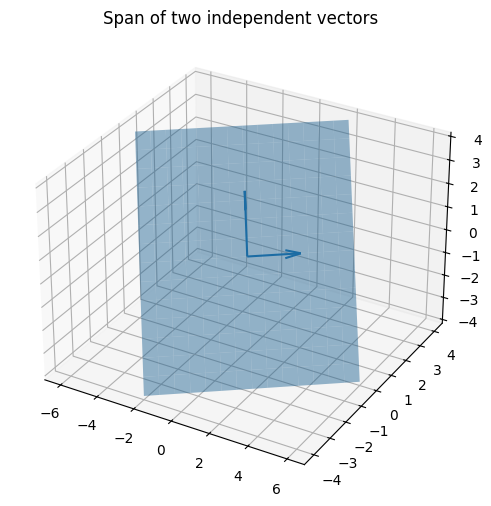

In [37]:
# Visualize the plane spanned by two independent vectors.
a=np.array([2.,1.,0.]); b=np.array([-1.,1.,2.])
s,t=np.meshgrid(np.linspace(-2,2,15),np.linspace(-2,2,15))
pts=s[...,None]*a+t[...,None]*b
fig=plt.figure(figsize=(7,6)); ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(pts[:,:,0],pts[:,:,1],pts[:,:,2],alpha=0.45)
ax.quiver(0,0,0,*a); ax.quiver(0,0,0,*b)
ax.set_title('Span of two independent vectors'); plt.show()

> **Closing note**
>
> Span asks whether vectors provide enough directions; independence asks whether any direction is redundant. A basis will require both.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Span | Set of all linear combinations of a set of vectors. |
| Spanning set | Set whose span equals the whole target space. |
| Linearly independent | Only the trivial homogeneous coefficient solution exists. |
| Linearly dependent | A nontrivial coefficient relation produces zero. |
| Trivial solution | All coefficients equal zero. |
| Dependence relation | Explicit nontrivial linear combination equal to zero. |

## Section 4.4 Worksheet — In-Class Practice

Work each problem before revealing the instructor solution.

### Problem 1

Determine whether $(8,1,7)$ is a linear combination of $(1,2,0)$, $(0,1,1)$, and $(2,0,1)$.

In [38]:
reveal_answer_key("4.4-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Determine whether $\{(1,0,1),(0,1,1),(1,1,2)\}$ is linearly independent.

In [39]:
reveal_answer_key("4.4-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Does $\{(1,2),(3,6)\}$ span $\mathbb{R}^2$? Explain.

In [40]:
reveal_answer_key("4.4-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Determine whether $\{1+x,\ x+x^2,\ 1+2x+x^2\}$ is independent in $P_2$.

In [41]:
reveal_answer_key("4.4-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Find a nontrivial dependence relation among $(1,0,2)$, $(0,1,1)$, and $(2,1,5)$.

In [42]:
reveal_answer_key("4.4-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Explain geometrically why two nonparallel vectors in $\mathbb{R}^2$ span the plane.

In [43]:
reveal_answer_key("4.4-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Section 4.5 - Basis and Dimension

## Learning objectives

Students should be able to:

- test whether a set is a basis;
- use standard bases for $\mathbb{R}^n$, $P_n$, and $M_{m,n}$;
- explain uniqueness of basis representation;
- find a basis for a subspace;
- compute dimensions and use dimension-based basis tests.

> **Definition: Basis**
>
> A **basis** for a vector space $V$ is a set of vectors that satisfies two requirements:
>
> 1. the vectors **span** $V$;
> 2. the vectors are **linearly independent**.
>
> Thus a basis contains enough vectors to generate the whole space, but no vector is redundant.
>
> This is why a basis can be viewed as a minimal coordinate system for $V$.

### Classroom Check: Why Does a Basis Need Two Conditions?

Why is “spans $V$” alone not enough for a basis, and why is “linearly independent” alone not enough?

In [44]:
reveal_answer_key("concept-4.5-basis", 'Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Standard bases

The standard basis for $\mathbb{R}^3$ is

$$
\mathbf{e}_1=(1,0,0),\; \mathbf{e}_2=(0,1,0),\; \mathbf{e}_3=(0,0,1).
$$

The standard basis for $P_2$ is

$$
\{1,x,x^2\}.
$$

A standard basis for $M_{2,2}$ is

$$
E_{11}=\begin{bmatrix}1&0\\0&0\end{bmatrix},\;
E_{12}=\begin{bmatrix}0&1\\0&0\end{bmatrix},\;
E_{21}=\begin{bmatrix}0&0\\1&0\end{bmatrix},\;
E_{22}=\begin{bmatrix}0&0\\0&1\end{bmatrix}.
$$

## Original basis example in $\mathbb{R}^3$

Let

$$
B=\{(1,2,0),(0,1,1),(2,0,1)\}.
$$

The basis matrix is

$$
M_B=\begin{bmatrix}1&0&2\\2&1&0\\0&1&1\end{bmatrix}.
$$

Because $\det(M_B)=5\ne0$, the columns are independent and span $\mathbb{R}^3$. Thus $B$ is a basis.

> **Uniqueness Theorem for a Basis**
>
> If
>
> $$
> B=\{\mathbf v_1,\ldots,\mathbf v_n\}
> $$
>
> is a basis for $V$, then every vector $\mathbf x\in V$ has exactly one representation
>
> $$
> \mathbf x=c_1\mathbf v_1+\cdots+c_n\mathbf v_n.
> $$
>
> **Why is the representation unique?** Suppose the same vector had two representations. Subtracting them would produce a nontrivial linear combination of the basis vectors equal to $\mathbf0$. That would contradict linear independence. Therefore the coefficients are unique.

## Extracting a Basis from a Spanning Set

Consider the set of vectors

$$
S=\{\mathbf v_1,\mathbf v_2,\mathbf v_3,\mathbf v_4\},
$$

where

$$
\mathbf v_1=
\begin{bmatrix}
1\\
2\\
0
\end{bmatrix},
\qquad
\mathbf v_2=
\begin{bmatrix}
0\\
1\\
1
\end{bmatrix},
\qquad
\mathbf v_3=
\begin{bmatrix}
2\\
0\\
1
\end{bmatrix},
\qquad
\mathbf v_4=
\begin{bmatrix}
1\\
3\\
1
\end{bmatrix}.
$$

Let

$$
W=\operatorname{span}(S).
$$

By definition, $S$ spans $W$ (**Every vector in $W$ can be written as a linear combination of vectors from $S$**).

However, a spanning set may contain **redundant vectors**. Our goal is to remove any redundant vectors while keeping the same span.

The remaining vectors should:

1. still span $W$;
2. be linearly independent.

A set satisfying both conditions is a **basis for $W$**.

---

### Step 1: Place the vectors as columns of a matrix

Form the matrix

$$
A=
\begin{bmatrix}
\mathbf v_1&\mathbf v_2&\mathbf v_3&\mathbf v_4
\end{bmatrix}
=
\begin{bmatrix}
1&0&2&1\\
2&1&0&3\\
0&1&1&1
\end{bmatrix}.
$$

We row-reduce $A$ to determine which columns provide independent directions.

The reduced row echelon form is

$$
\operatorname{rref}(A)
=
\begin{bmatrix}
1&0&0&1\\
0&1&0&1\\
0&0&1&0
\end{bmatrix}.
$$

The pivot positions occur in columns

$$
1,\;2,\;3.
$$

Therefore, the corresponding columns of the **original matrix**

$$
\mathbf v_1,\mathbf v_2,\mathbf v_3
$$

are the essential vectors.

The fourth column is a nonpivot column, so it does not contribute a new independent direction.

Thus,

$$
\boxed{
\{\mathbf v_1,\mathbf v_2,\mathbf v_3\}
}
$$

is a candidate for a basis of $W$.

---

### Step 2: Understand why $\mathbf v_4$ is redundant

Look at the fourth column of the RREF:

$$
\begin{bmatrix}
1\\
1\\
0
\end{bmatrix}.
$$

The first three columns of the RREF are

$$
\mathbf e_1,\qquad
\mathbf e_2,\qquad
\mathbf e_3.
$$

Therefore,

$$
\begin{bmatrix}
1\\
1\\
0
\end{bmatrix}
=
1\mathbf e_1
+
1\mathbf e_2
+
0\mathbf e_3.
$$

Row operations preserve the linear relationships among the columns. Therefore, the same coefficients describe the relationship among the corresponding columns of the original matrix:

$$
\boxed{
\mathbf v_4
=
\mathbf v_1+\mathbf v_2.
}
$$

We can verify this directly:

$$
\begin{bmatrix}
1\\
2\\
0
\end{bmatrix}
+
\begin{bmatrix}
0\\
1\\
1
\end{bmatrix}
=
\begin{bmatrix}
1\\
3\\
1
\end{bmatrix}
=
\mathbf v_4.
$$

Thus, $\mathbf v_4$ is already generated by $\mathbf v_1$ and $\mathbf v_2$.

It does not add anything new to the span.

Therefore,

$$
\operatorname{span}
\{\mathbf v_1,\mathbf v_2,\mathbf v_3,\mathbf v_4\}
=
\operatorname{span}
\{\mathbf v_1,\mathbf v_2,\mathbf v_3\}.
$$

So removing $\mathbf v_4$ does not change the space $W$.

---

### Step 3: Why do the remaining vectors form a basis?

The vectors

$$
\mathbf v_1,\mathbf v_2,\mathbf v_3
$$

correspond to pivot columns, so they are linearly independent.

We also showed that

$$
\operatorname{span}
\{\mathbf v_1,\mathbf v_2,\mathbf v_3\}
=
W.
$$

Therefore, the set

$$
\{\mathbf v_1,\mathbf v_2,\mathbf v_3\}
$$

satisfies both requirements for a basis:

$$
\boxed{
\text{it spans }W
}
$$

and

$$
\boxed{
\text{it is linearly independent}.
}
$$

Hence,

$$
\boxed{
\{\mathbf v_1,\mathbf v_2,\mathbf v_3\}
\text{ is a basis for }W.
}
$$

---

### General Procedure: Extracting a Basis from a Set of Vectors

Suppose

$$
S=\{\mathbf v_1,\mathbf v_2,\ldots,\mathbf v_k\}
$$

and let

$$
W=\operatorname{span}(S).
$$

To extract a basis for $W$ from the vectors in $S$:

1. Place the vectors as columns of a matrix:

$$
A=
\begin{bmatrix}
\mathbf v_1&\mathbf v_2&\cdots&\mathbf v_k
\end{bmatrix}.
$$

2. Row-reduce $A$ and identify the pivot columns.

3. Return to the **original matrix $A$**.

4. Select the original columns corresponding to the pivot positions.

These original pivot columns form a basis for

$$
W=\operatorname{span}(S).
$$

> **Important:** The RREF tells us **which column positions are pivot positions**, but the basis vectors must be taken from the **original matrix**, not from the RREF.

The role of row reduction is to identify which original vectors are essential and which ones are redundant.

In [45]:
Smat=sp.Matrix.hstack(sp.Matrix([1,2,0]),sp.Matrix([0,1,1]),sp.Matrix([2,0,1]),sp.Matrix([1,3,1]))
R,pivs=Smat.rref()
show_matrix(Smat,'S')
show_matrix(R,r'\operatorname{rref}(S)')
print('Pivot-column indices (0-based Python):', pivs)
print('Mathematical pivot columns (1-based):', tuple(j+1 for j in pivs))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Pivot-column indices (0-based Python): (0, 1, 2)
Mathematical pivot columns (1-based): (1, 2, 3)


> **Definition: Dimension**
>
> If a vector space $V$ has a finite basis, then every basis of $V$ contains the same number of vectors.
>
> That number is called the **dimension** of $V$ and is written
>
> $$
> \dim(V).
> $$
>
> Thus dimension counts the number of independent directions needed to describe the space. The zero vector space $\{\mathbf0\}$ has dimension $0$.

## Dimension of common spaces

$$
\dim(\mathbb{R}^n)=n,
\;
\dim(P_n)=n+1,
\;
\dim(M_{m,n})=mn.
$$

## Dimension of a Parametrized Subspace

Let

$$
W=\{(a+b,a-b,2a):a,b\in\mathbb R\}.
$$

Rewrite a general vector in $W$:

$$
(a+b,a-b,2a)
=
a(1,1,2)+b(1,-1,0).
$$

Therefore,

$$
W=
\operatorname{span}
\{(1,1,2),(1,-1,0)\}.
$$

The two spanning vectors are not scalar multiples of one another, so they are linearly independent.

Thus,

$$
\boxed{
\{(1,1,2),(1,-1,0)\}
}
$$

is a basis for $W$.

Since this basis contains two vectors,

$$
\boxed{\dim(W)=2.}
$$

## Polynomial subspace with a condition

Let

$$
W=\{p\in P_3:p(1)=0\}.
$$

Every $p\in W$ is divisible by $x-1$. One basis is

$$
\{x-1,\ x(x-1),\ x^2(x-1)\}
=
\{x-1,\ x^2-x,\ x^3-x^2\}.
$$

Thus $\dim(W)=3$.

## Basis tests in an $n$-dimensional space

If $\dim(V)=n$, then:

- any independent set of exactly $n$ vectors is a basis;
- any spanning set of exactly $n$ vectors is a basis;
- any set with more than $n$ vectors is dependent;
- any set with fewer than $n$ vectors cannot span $V$.

### Classroom Check: Dimension as a Counting Tool

If $\dim(V)=n$, what can we immediately conclude about a set containing more than $n$ vectors? What about fewer than $n$ vectors?

In [46]:
reveal_answer_key("concept-4.5-dimension", 'Reveal dimension check')

ToggleButton(value=False, button_style='info', description='Reveal dimension check', icon='eye', layout=Layout…

> **Closing note**
>
> Dimension measures the number of independent directions in a space. A basis provides a minimal coordinate system for those directions.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Basis | Linearly independent spanning set. |
| Standard basis | Natural coordinate basis for a familiar vector space. |
| Finite-dimensional | Has a basis with finitely many vectors. |
| Dimension | Number of vectors in any basis. |
| Basis extraction | Removing redundant vectors while preserving span. |
| Unique representation | Each vector has exactly one coefficient list relative to a basis. |

## Section 4.5 Worksheet — In-Class Practice

Work each problem before revealing the instructor solution.

### Problem 1

Determine whether $\{(1,0,1),(0,1,1),(1,1,0)\}$ is a basis for $\mathbb{R}^3$.

In [47]:
reveal_answer_key("4.5-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Find the dimension of $\operatorname{span}\{(1,2,0),(0,1,1),(1,3,1)\}$.

In [48]:
reveal_answer_key("4.5-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Give a standard basis and dimension for $P_4$.

In [49]:
reveal_answer_key("4.5-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Give a basis and dimension for the symmetric $2\times2$ matrices.

In [50]:
reveal_answer_key("4.5-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Find a basis and dimension for $W=\{(s+t,s-t,3s):s,t\in\mathbb{R}\}$.

In [51]:
reveal_answer_key("4.5-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Explain why five vectors in $P_3$ must be linearly dependent.

In [52]:
reveal_answer_key("4.5-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Section 4.6 - Rank of a Matrix and Systems of Linear Equations

## Learning objectives

Students should be able to:

- find bases for row and column spaces;
- compute rank and nullity;
- find a basis for the nullspace;
- apply the rank-nullity theorem;
- express nonhomogeneous solutions as $\mathbf{x}_p+\mathbf{x}_h$;
- interpret consistency using the column space.

> **Definitions: Row Space and Column Space**
>
> Let $A$ be an $m\times n$ matrix.
>
> - The **row space** of $A$, denoted $\operatorname{Row}(A)$, is the span of the rows of $A$. It is a subspace of $\mathbb R^n$.
> - The **column space** of $A$, denoted $\operatorname{Col}(A)$, is the span of the columns of $A$. It is a subspace of $\mathbb R^m$.
>
> The column-space interpretation is especially important because
>
> $$
> A\mathbf x
> $$
>
> is a linear combination of the columns of $A$, using the entries of $\mathbf x$ as coefficients.

## A shared matrix for the section

Let

$$
A=\begin{bmatrix}
1&1&1&0&1\\
2&1&3&1&3\\
1&0&2&2&5
\end{bmatrix}.
$$

Its reduced row-echelon form is

$$
R=\begin{bmatrix}
1&0&2&0&-1\\
0&1&-1&0&2\\
0&0&0&1&3
\end{bmatrix}.
$$

The pivot columns are $1$, $2$, and $4$.

In [53]:
A46=sp.Matrix([[1,1,1,0,1],[2,1,3,1,3],[1,0,2,2,5]])
R46,p46=A46.rref()
show_matrix(A46,'A')
show_matrix(R46,'R')
print('Pivot-column indices (0-based Python):', p46)
print('Mathematical pivot columns (1-based):', tuple(j+1 for j in p46))
print('Rank:', A46.rank())

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Pivot-column indices (0-based Python): (0, 1, 3)
Mathematical pivot columns (1-based): (1, 2, 4)
Rank: 3


## Basis for the Row Space

Elementary row operations replace rows by linear combinations of rows, so they **preserve the row space**. Therefore, the nonzero rows of an echelon form (or RREF) form a basis for the original row space.

For

$$
R=\begin{bmatrix}
1&0&2&0&-1\\
0&1&-1&0&2\\
0&0&0&1&3
\end{bmatrix},
$$

one row-space basis is

$$
\boxed{\{(1,0,2,0,-1),(0,1,-1,0,2),(0,0,0,1,3)\}}.
$$

## Basis for the Column Space

The pivot positions in the RREF occur in columns $1$, $2$, and $4$.

These pivot positions tell us **which original columns are independent**, but the basis vectors for $\operatorname{Col}(A)$ must be selected from the original matrix $A$:

$$
\boxed{
\left\{
\begin{bmatrix}1\\2\\1\end{bmatrix},
\begin{bmatrix}1\\1\\0\end{bmatrix},
\begin{bmatrix}0\\1\\2\end{bmatrix}
\right\}
}.
$$

Why not use the pivot columns of the RREF itself? Row operations generally change the actual column vectors and can change the column space. They preserve the **dependence relationships and pivot locations**, but not the original column space as a set of vectors.

### Classroom Check: Why Original Columns?

Why can we use the nonzero rows of the RREF for a row-space basis, but must return to the **original matrix** for a column-space basis?

In [54]:
reveal_answer_key("concept-4.6-row-col", 'Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

> **Definition: Rank**
>
> The **rank** of a matrix $A$ is the dimension of its row space. A fundamental theorem states that this is also the dimension of its column space:
>
> $$
> \operatorname{rank}(A)
> =\dim(\operatorname{Row}(A))
> =\dim(\operatorname{Col}(A)).
> $$
>
> Equivalently, rank is the number of pivot positions in an echelon form of $A$. For the matrix in this section,
>
> $$
> \operatorname{rank}(A)=3.
> $$

> **Definition: Nullspace and Nullity**
>
> For an $m\times n$ matrix $A$, the **nullspace** is
>
> $$
> N(A)=\{\mathbf x\in\mathbb R^n:A\mathbf x=\mathbf0\}.
> $$
>
> It is a subspace of $\mathbb R^n$ because it is the solution set of a homogeneous linear system.
>
> The **nullity** of $A$ is the dimension of this nullspace:
>
> $$
> \operatorname{nullity}(A)=\dim N(A).
> $$

## Detailed nullspace calculation

From the RREF,

$$
\begin{aligned}
x_1+2x_3-x_5&=0,\\
x_2-x_3+2x_5&=0,\\
x_4+3x_5&=0.
\end{aligned}
$$

Let the free variables be

$$
x_3=s,\; x_5=t.
$$

Then

$$
x_1=-2s+t,
\;
x_2=s-2t,
\;
x_4=-3t.
$$

Therefore,

$$
\mathbf{x}=
\begin{bmatrix}-2s+t\\s-2t\\s\\-3t\\t\end{bmatrix}
=s\begin{bmatrix}-2\\1\\1\\0\\0\end{bmatrix}
+t\begin{bmatrix}1\\-2\\0\\-3\\1\end{bmatrix}.
$$

A basis for $N(A)$ is

$$
\left\{
\begin{bmatrix}-2\\1\\1\\0\\0\end{bmatrix},
\begin{bmatrix}1\\-2\\0\\-3\\1\end{bmatrix}
\right\}.
$$

In [55]:
null_basis=A46.nullspace()
for i,v in enumerate(null_basis,1): show_vector(v,rf'\mathbf{{n}}_{i}')
print('rank + nullity =',A46.rank()+len(null_basis),'= number of columns')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

rank + nullity = 5 = number of columns


> **Rank-Nullity Theorem**
>
> If $A$ is an $m\times n$ matrix, then
>
> $$
> \boxed{n=\operatorname{rank}(A)+\operatorname{nullity}(A)}.
> $$
>
> The number $n$ is the number of columns, or equivalently the number of input coordinates in $\mathbf x$.
>
> Rank counts pivot directions; nullity counts the independent free-variable directions in the nullspace. For the matrix in this section,
>
> $$
> 5=3+2.
> $$

### Classroom Check: What Does Rank-Nullity Count?

In

$$
n=\operatorname{rank}(A)+\operatorname{nullity}(A),
$$

what do the two terms count?

In [56]:
reveal_answer_key("concept-4.6-rank-nullity", 'Reveal interpretation')

ToggleButton(value=False, button_style='info', description='Reveal interpretation', icon='eye', layout=Layout(…

## Nonhomogeneous systems: $\mathbf{x}_p+\mathbf{x}_h$

Consider

$$
A\mathbf{x}=\mathbf{b},
\;
\mathbf{b}=\begin{bmatrix}6\\12\\14\end{bmatrix}.
$$

One particular solution is

$$
\mathbf{x}_p=\begin{bmatrix}1\\2\\0\\-1\\3\end{bmatrix},
$$

because $A\mathbf{x}_p=\mathbf{b}$. Every solution is

$$
\mathbf{x}=\mathbf{x}_p+\mathbf{x}_h,
$$

where $\mathbf{x}_h\in N(A)$. Hence

$$
\mathbf{x}=
\begin{bmatrix}1\\2\\0\\-1\\3\end{bmatrix}
+s\begin{bmatrix}-2\\1\\1\\0\\0\end{bmatrix}
+t\begin{bmatrix}1\\-2\\0\\-3\\1\end{bmatrix}.
$$

In [57]:
xp=sp.Matrix([1,2,0,-1,3]); b46=A46*xp
show_vector(b46,r'\mathbf{b}')
print('Verification A*xp=b:',A46*xp==b46)

<IPython.core.display.Math object>

Verification A*xp=b: True


## Consistency and the column space

The system $A\mathbf{x}=\mathbf{b}$ is consistent if and only if $\mathbf{b}$ lies in $\operatorname{Col}(A)$. The coefficients of a solution express $\mathbf{b}$ as a linear combination of the columns of $A$.

### Classroom Check: Consistency and Column Space

Why is

$$
A\mathbf x=\mathbf b
$$

consistent exactly when $\mathbf b\in\operatorname{Col}(A)$?

In [58]:
reveal_answer_key("concept-4.6-consistency", 'Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Equivalent Conditions for a Square Matrix

For an $n\times n$ matrix $A$, the following statements are equivalent. If any one is true, then all are true:

- $A$ is invertible;
- $A\mathbf{x}=\mathbf{b}$ has a unique solution for every $\mathbf b\in\mathbb R^n$;
- $A\mathbf{x}=\mathbf0$ has only the trivial solution;
- $A$ is row-equivalent to $I_n$;
- $\det(A)\ne0$;
- $\operatorname{rank}(A)=n$;
- the rows of $A$ are linearly independent;
- the columns of $A$ are linearly independent;
- the columns of $A$ span $\mathbb R^n$;
- the columns of $A$ form a basis for $\mathbb R^n$.

This theorem connects the computational ideas from row reduction and determinants with the structural ideas of independence, span, basis, and rank.

> **Common mistake**
>
> Pivot columns are located using the RREF, but a column-space basis must be taken from the original matrix.

> **Closing note**
>
> Rank counts independent output directions; nullity counts independent input directions that are lost. Together they account for every input coordinate.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Row space | Span of matrix rows. |
| Column space | Span of matrix columns. |
| Rank | Dimension of row or column space. |
| Nullspace | Solution space of $A\mathbf{x}=0$. |
| Nullity | Dimension of the nullspace. |
| Pivot column | Column corresponding to a leading entry in echelon form. |
| Particular solution | One solution of a nonhomogeneous system. |
| Homogeneous solution | Any vector in the nullspace. |
| Rank-nullity theorem | $n=\operatorname{rank}(A)+\operatorname{nullity}(A)$. |

## Section 4.6 Worksheet — In-Class Practice

Work each problem before revealing the instructor solution.

### Problem 1

For

$$
B=\begin{bmatrix}
1&2&0&1\\
2&4&1&3\\
-1&-2&1&0
\end{bmatrix},
$$

find the RREF and rank of $B$.

In [59]:
reveal_answer_key("4.6-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Using the same matrix $B$, find a basis for the row space.

In [60]:
reveal_answer_key("4.6-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Using the same matrix $B$, find a basis for the column space using columns of the original matrix.

In [61]:
reveal_answer_key("4.6-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Using the same matrix $B$, find a basis for $N(B)$ and the nullity.

In [62]:
reveal_answer_key("4.6-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Verify the rank-nullity theorem for the matrix $B$.

In [63]:
reveal_answer_key("4.6-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

If $\mathbf{x}_p=(1,0,2,-1)^T$, compute $\mathbf{b}=B\mathbf{x}_p$ and write the complete solution of $B\mathbf{x}=\mathbf{b}$ as $\mathbf{x}_p+\mathbf{x}_h$.

In [64]:
reveal_answer_key("4.6-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Section 4.7 - Coordinates and Change of Basis

## Learning objectives

Students should be able to:

- find coordinates relative to an ordered basis;
- reconstruct a vector from its coordinates;
- compute transition matrices between bases;
- convert coordinate vectors in both directions;
- represent polynomials and matrices using nonstandard bases.

> **Definition: Coordinate Vector**
>
> Let
>
> $$
> B=\{\mathbf v_1,\ldots,\mathbf v_n\}
> $$
>
> be an **ordered basis** for $V$. If
>
> $$
> \mathbf x=c_1\mathbf v_1+\cdots+c_n\mathbf v_n,
> $$
>
> then the coordinate vector of $\mathbf x$ relative to $B$ is
>
> $$
> [\mathbf x]_B=
> \begin{bmatrix}
> c_1\\
> \vdots\\
> c_n
> \end{bmatrix}.
> $$
>
> The vector $\mathbf x$ itself has not changed. The coordinate vector records how $\mathbf x$ is assembled from the ordered basis $B$.

## Coordinates in a nonstandard basis

Let

$$
B=\{(1,1),(1,-1)\},
\;
\mathbf{x}=(9,21).
$$

We solve

$$
c_1(1,1)+c_2(1,-1)=(9,21).
$$

This gives

$$
c_1+c_2=9,
\;
c_1-c_2=21.
$$

Adding the equations gives $2c_1=30$, so $c_1=15$. Then $c_2=-6$. Therefore,

$$
[\mathbf{x}]_B=\begin{bmatrix}15\\-6\end{bmatrix}.
$$

In [65]:
B2=[sp.Matrix([1,1]),sp.Matrix([1,-1])]
x2=sp.Matrix([9,21])
show_vector(coordinate_vector(B2,x2),r'[\mathbf{x}]_B')

<IPython.core.display.Math object>

⎡15⎤
⎢  ⎥
⎣-6⎦

## Coordinate geometry

The vector itself does not change when the basis changes. Only its coordinate description changes. Relative to the standard basis,

$$
[\mathbf{x}]_S=\begin{bmatrix}9\\21\end{bmatrix},
$$

while relative to $B$,

$$
[\mathbf{x}]_B=\begin{bmatrix}15\\-6\end{bmatrix}.
$$

### Classroom Check: Did the Vector Change?

When we change from $[\mathbf x]_S$ to $[\mathbf x]_B$, has the underlying vector $\mathbf x$ changed?

In [66]:
reveal_answer_key("concept-4.7-vector-coordinates", 'Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

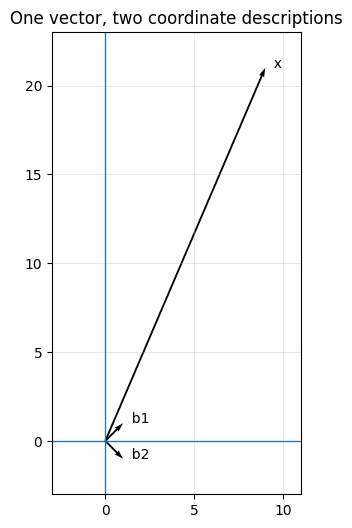

In [67]:
fig,ax=plt.subplots(figsize=(7,6))
plot_vector2([1,1],'b1',ax=ax)
plot_vector2([1,-1],'b2',ax=ax)
plot_vector2([9,21],'x',ax=ax)
ax.set_xlim(-3,11); ax.set_ylim(-3,23); ax.set_aspect('equal'); ax.set_title('One vector, two coordinate descriptions')
plt.show()

> **Definition: Transition Matrix**
>
> Let
>
> $$
> B=\{\mathbf b_1,\mathbf b_2,\ldots,\mathbf b_n\}
> $$
>
> and
>
> $$
> C=\{\mathbf c_1,\mathbf c_2,\ldots,\mathbf c_n\}
> $$
>
> be two ordered bases for the same vector space $V$.
>
> The **transition matrix from basis $B$ to basis $C$** is denoted by
>
> $$
> P_{C\leftarrow B}.
> $$
>
> Its purpose is to convert the coordinate vector of $\mathbf x$ relative to basis $B$ into the coordinate vector of the same vector $\mathbf x$ relative to basis $C$:
>
> $$
> \boxed{
> [\mathbf x]_C
> =
> P_{C\leftarrow B}[\mathbf x]_B
> }.
> $$
>
> Read
>
> $$
> C\leftarrow B
> $$
>
> as
>
> $$
> \boxed{\text{from }B\text{-coordinates to }C\text{-coordinates}.}
> $$
>
> The vector $\mathbf x$ itself does not change. Only its coordinate representation changes.

---

### How is the transition matrix constructed?

Each basis vector in $B$ can be expressed as a linear combination of the basis vectors in $C$.

For example,

$$
\mathbf b_j
=
a_{1j}\mathbf c_1
+
a_{2j}\mathbf c_2
+
\cdots
+
a_{nj}\mathbf c_n.
$$

Therefore, the $C$-coordinate vector of $\mathbf b_j$ is

$$
[\mathbf b_j]_C
=
\begin{bmatrix}
a_{1j}\\
a_{2j}\\
\vdots\\
a_{nj}
\end{bmatrix}.
$$

These coordinate vectors become the columns of the transition matrix:

$$
\boxed{
P_{C\leftarrow B}
=
\begin{bmatrix}
[\mathbf b_1]_C
&
[\mathbf b_2]_C
&
\cdots
&
[\mathbf b_n]_C
\end{bmatrix}.
}
$$

So the $j$th column of $P_{C\leftarrow B}$ tells us how the basis vector $\mathbf b_j$ is represented using basis $C$.

---

### Why do these columns work?

Suppose

$$
[\mathbf x]_B
=
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_n
\end{bmatrix}.
$$

This means

$$
\mathbf x
=
x_1\mathbf b_1
+
x_2\mathbf b_2
+
\cdots
+
x_n\mathbf b_n.
$$

Taking $C$-coordinates gives

$$
[\mathbf x]_C
=
x_1[\mathbf b_1]_C
+
x_2[\mathbf b_2]_C
+
\cdots
+
x_n[\mathbf b_n]_C.
$$

But this is exactly matrix multiplication:

$$
[\mathbf x]_C
=
\begin{bmatrix}
[\mathbf b_1]_C
&
[\mathbf b_2]_C
&
\cdots
&
[\mathbf b_n]_C
\end{bmatrix}
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_n
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
[\mathbf x]_C
=
P_{C\leftarrow B}[\mathbf x]_B.
}
$$

---

### Reversing the direction

If

$$
P_{C\leftarrow B}
$$

converts $B$-coordinates into $C$-coordinates, then the reverse transition matrix

$$
P_{B\leftarrow C}
$$

converts $C$-coordinates back into $B$-coordinates.

The two matrices are inverses:

$$
\boxed{
P_{B\leftarrow C}
=
\left(P_{C\leftarrow B}\right)^{-1}.
}
$$

Equivalently,

$$
\boxed{
P_{B\leftarrow C}P_{C\leftarrow B}=I.
}
$$

A useful way to remember the notation is:

$$
\boxed{
\text{destination}\leftarrow\text{source}.
}
$$

So

$$
P_{C\leftarrow B}
$$

means:

$$
\boxed{
B\text{-coordinates}
\longrightarrow
C\text{-coordinates}.
}
$$

### Classroom Check: Read the Arrow

What direction does

$$
P_{C\leftarrow B}
$$

convert coordinates, and what matrix converts in the reverse direction?

In [68]:
reveal_answer_key("concept-4.7-direction", 'Reveal transition rule')

ToggleButton(value=False, button_style='info', description='Reveal transition rule', icon='eye', layout=Layout…

## Detailed $3\times3$ change of basis

Let

$$
B=\{(1,1,0),(0,1,1),(1,0,1)\},
$$

and

$$
C=\{(1,0,0),(1,1,0),(1,1,1)\}.
$$

The basis matrices are

$$
M_B=\begin{bmatrix}1&0&1\\1&1&0\\0&1&1\end{bmatrix},
\;
M_C=\begin{bmatrix}1&1&1\\0&1&1\\0&0&1\end{bmatrix}.
$$

Since

$$
\mathbf{x}=M_B[\mathbf{x}]_B=M_C[\mathbf{x}]_C,
$$

we obtain

$$
[\mathbf{x}]_C=M_C^{-1}M_B[\mathbf{x}]_B.
$$

Thus

$$
P_{C\leftarrow B}=M_C^{-1}M_B
=\begin{bmatrix}
0&-1&1\\
1&0&-1\\
0&1&1
\end{bmatrix}.
$$

In [69]:
MB=sp.Matrix([[1,0,1],[1,1,0],[0,1,1]])
MC=sp.Matrix([[1,1,1],[0,1,1],[0,0,1]])
P_CB=MC.inv()*MB
show_matrix(MB,'M_B'); show_matrix(MC,'M_C'); show_matrix(P_CB,r'P_{C\leftarrow B}')
show_matrix(P_CB.inv(),r'P_{B\leftarrow C}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡1/2   1  1/2⎤
⎢            ⎥
⎢-1/2  0  1/2⎥
⎢            ⎥
⎣1/2   0  1/2⎦

## Gauss-Jordan construction of the transition matrix

To compute $P_{C\leftarrow B}$ without separately finding $M_C^{-1}$, row reduce

$$
[M_C\mid M_B].
$$

Start with

$$
\left[
\begin{array}{ccc|ccc}
1&1&1&1&0&1\\
0&1&1&1&1&0\\
0&0&1&0&1&1
\end{array}
\right].
$$

Apply $R_2\leftarrow R_2-R_3$:

$$
\left[
\begin{array}{ccc|ccc}
1&1&1&1&0&1\\
0&1&0&1&0&-1\\
0&0&1&0&1&1
\end{array}
\right].
$$

Apply $R_1\leftarrow R_1-R_3$:

$$
\left[
\begin{array}{ccc|ccc}
1&1&0&1&-1&0\\
0&1&0&1&0&-1\\
0&0&1&0&1&1
\end{array}
\right].
$$

Apply $R_1\leftarrow R_1-R_2$:

$$
\left[
\begin{array}{ccc|ccc}
1&0&0&0&-1&1\\
0&1&0&1&0&-1\\
0&0&1&0&1&1
\end{array}
\right].
$$

The right block is $P_{C\leftarrow B}$.

### Why Does Row Reduction Produce the Transition Matrix?

Let

$$
B=\{\mathbf b_1,\mathbf b_2,\mathbf b_3\}
$$

and

$$
C=\{\mathbf c_1,\mathbf c_2,\mathbf c_3\}
$$

be two ordered bases for the same vector space.

Form the basis matrices

$$
M_B=
\begin{bmatrix}
\mathbf b_1&\mathbf b_2&\mathbf b_3
\end{bmatrix}
$$

and

$$
M_C=
\begin{bmatrix}
\mathbf c_1&\mathbf c_2&\mathbf c_3
\end{bmatrix}.
$$

The columns are written in standard coordinates.

Because $C$ is a basis, the matrix $M_C$ is invertible.

---

### First recall the transition-matrix formula

For any vector $\mathbf x$,

$$
\mathbf x=M_B[\mathbf x]_B.
$$

At the same time,

$$
\mathbf x=M_C[\mathbf x]_C.
$$

Therefore,

$$
M_C[\mathbf x]_C
=
M_B[\mathbf x]_B.
$$

Multiply both sides by $M_C^{-1}$:

$$
[\mathbf x]_C
=
M_C^{-1}M_B[\mathbf x]_B.
$$

But by definition,

$$
[\mathbf x]_C
=
P_{C\leftarrow B}[\mathbf x]_B.
$$

Therefore,

$$
\boxed{
P_{C\leftarrow B}
=
M_C^{-1}M_B.
}
$$

So our goal is really to compute

$$
M_C^{-1}M_B.
$$

---

### Why does Gauss--Jordan elimination compute this product?

Start with the augmented matrix

$$
\left[
M_C\mid M_B
\right].
$$

Row operations can be represented by multiplication on the left by an invertible matrix $E$.

Therefore, after performing a sequence of row operations,

$$
\left[
M_C\mid M_B
\right]
\longrightarrow
\left[
EM_C\mid EM_B
\right].
$$

We choose the row operations so that the left block becomes the identity matrix:

$$
EM_C=I.
$$

Since $M_C$ is invertible,

$$
E=M_C^{-1}.
$$

Therefore, the same row operations transform the right block into

$$
EM_B
=
M_C^{-1}M_B.
$$

Hence,

$$
\left[
M_C\mid M_B
\right]
\longrightarrow
\left[
I\mid M_C^{-1}M_B
\right].
$$

Since

$$
P_{C\leftarrow B}=M_C^{-1}M_B,
$$

we obtain

$$
\boxed{
\left[
M_C\mid M_B
\right]
\longrightarrow
\left[
I\mid P_{C\leftarrow B}
\right].
}
$$

This is why the right block after Gauss--Jordan elimination is the transition matrix.

---

### Another Interpretation: We Are Solving Several Systems at Once

There is another useful way to understand the same procedure.

Recall that

$$
P_{C\leftarrow B}
=
\begin{bmatrix}
[\mathbf b_1]_C&
[\mathbf b_2]_C&
[\mathbf b_3]_C
\end{bmatrix}.
$$

To find the first column, we need to express $\mathbf b_1$ using the basis $C$.

Suppose

$$
[\mathbf b_1]_C
=
\begin{bmatrix}
a_1\\
a_2\\
a_3
\end{bmatrix}.
$$

Then

$$
\mathbf b_1
=
a_1\mathbf c_1
+
a_2\mathbf c_2
+
a_3\mathbf c_3.
$$

In matrix form,

$$
M_C
\begin{bmatrix}
a_1\\
a_2\\
a_3
\end{bmatrix}
=
\mathbf b_1.
$$

Therefore,

$$
M_C[\mathbf b_1]_C=\mathbf b_1.
$$

Similarly,

$$
M_C[\mathbf b_2]_C=\mathbf b_2
$$

and

$$
M_C[\mathbf b_3]_C=\mathbf b_3.
$$

Instead of solving these three systems separately,

$$
M_C\mathbf y_1=\mathbf b_1,
$$

$$
M_C\mathbf y_2=\mathbf b_2,
$$

$$
M_C\mathbf y_3=\mathbf b_3,
$$

we place all three right-hand sides together:

$$
\left[
M_C
\mid
\mathbf b_1
\quad
\mathbf b_2
\quad
\mathbf b_3
\right].
$$

But

$$
\begin{bmatrix}
\mathbf b_1&
\mathbf b_2&
\mathbf b_3
\end{bmatrix}
=
M_B.
$$

Therefore, we row-reduce

$$
\boxed{
[M_C\mid M_B].
}
$$

After reduction,

$$
\left[
M_C\mid M_B
\right]
\longrightarrow
\left[
I
\mid
[\mathbf b_1]_C
\quad
[\mathbf b_2]_C
\quad
[\mathbf b_3]_C
\right].
$$

Thus,

$$
\boxed{
P_{C\leftarrow B}
=
\begin{bmatrix}
[\mathbf b_1]_C&
[\mathbf b_2]_C&
[\mathbf b_3]_C
\end{bmatrix}.
}
$$

So Gauss--Jordan elimination is simply finding the $C$-coordinates of all the $B$-basis vectors **simultaneously**.

## Converting a vector

For

$$
\mathbf{x}=(9,20,21),
$$

one finds

$$
[\mathbf{x}]_B=\begin{bmatrix}4\\16\\5\end{bmatrix}.
$$

Then

$$
[\mathbf{x}]_C=P_{C\leftarrow B}[\mathbf{x}]_B
=\begin{bmatrix}-11\\-1\\21\end{bmatrix}.
$$

In [70]:
x3=sp.Matrix([9,20,21])
cB=MB.LUsolve(x3); cC=MC.LUsolve(x3)
show_vector(cB,r'[\mathbf{x}]_B'); show_vector(P_CB*cB,r'P_{C\leftarrow B}[\mathbf{x}]_B'); show_vector(cC,r'[\mathbf{x}]_C')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡-11⎤
⎢   ⎥
⎢-1 ⎥
⎢   ⎥
⎣21 ⎦

## Coordinates in $P_3$

Relative to the ordered basis

$$
B=\{1,\ x-1,\ (x-1)^2,\ (x-1)^3\},
$$

write

$$
p(x)=2+3x-x^2+x^3.
$$

Expanding around $x=1$ gives

$$
p(x)=5+4(x-1)+2(x-1)^2+(x-1)^3.
$$

Therefore,

$$
[p]_B=\begin{bmatrix}5\\4\\2\\1\end{bmatrix}.
$$

In [71]:
x=sp.symbols('x')
p=2+3*x-x**2+x**3
q=sp.expand(p.subs(x,sp.symbols('t')+1))
print(q)

t**3 + 2*t**2 + 4*t + 5


> **Common mistake**
>
> A transition matrix depends on direction. Always write the arrow notation $P_{C\leftarrow B}$ before calculating.

> **Closing note**
>
> Coordinates are labels relative to a basis. Change of basis changes the labels, not the underlying vector.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Ordered basis | Basis whose vector order is fixed. |
| Coordinate vector | Coefficients of a vector relative to an ordered basis. |
| Basis matrix | Matrix whose columns are basis vectors. |
| Transition matrix | Matrix converting coordinates from one basis to another. |
| Change of basis | Re-expression of the same vector in a different coordinate system. |

## Section 4.7 Worksheet — In-Class Practice

Work each problem before revealing the instructor solution.

### Problem 1

For $B=\{(1,2),(2,-1)\}$, find $[(8,7)]_B$.

In [72]:
reveal_answer_key("4.7-1", "Reveal Problem 1")

Solve

$$
c_1(1,2)+c_2(2,-1)=(8,7).
$$

This gives

$$
c_1+2c_2=8,
$$

and

$$
2c_1-c_2=7.
$$

The solution is

$$
c_1=\frac{22}{5},\; c_2=\frac95.
$$

Thus

$$
\boxed{[(8,7)]_B=\begin{bmatrix}22/5\\9/5\end{bmatrix}}.
$$

### Problem 2

Reconstruct $\mathbf{x}$ from $[\mathbf{x}]_B=(3,-2)^T$ using the same basis.

In [73]:
reveal_answer_key("4.7-2", "Reveal Problem 2")

Use the coordinates as coefficients of the ordered basis vectors:

$$
\mathbf x=3(1,2)-2(2,-1).
$$

Therefore,

$$
\boxed{\mathbf x=(-1,8)}.
$$

### Problem 3

Let $B=\{(1,1),(1,-1)\}$ and $S$ be the standard basis. Find $P_{S\leftarrow B}$ and $P_{B\leftarrow S}$.

In [74]:
reveal_answer_key("4.7-3", "Reveal Problem 3")

The columns of $P_{S\leftarrow B}$ are the standard-coordinate vectors of the basis $B$:

$$
P_{S\leftarrow B}=\begin{bmatrix}1&1\\1&-1\end{bmatrix}.
$$

The reverse transition matrix is its inverse:

$$
P_{B\leftarrow S}
=\frac12\begin{bmatrix}1&1\\1&-1\end{bmatrix}.
$$

### Problem 4

Use the transition matrix to convert $[\mathbf{x}]_B=(5,4)^T$ to standard coordinates.

In [75]:
reveal_answer_key("4.7-4", "Reveal Problem 4")

Use

$$
[\mathbf x]_S=P_{S\leftarrow B}[\mathbf x]_B.
$$

Then

$$
\begin{bmatrix}1&1\\1&-1\end{bmatrix}
\begin{bmatrix}5\\4\end{bmatrix}
=
\begin{bmatrix}9\\1\end{bmatrix}.
$$

Thus the standard coordinates are

$$
\boxed{(9,1)}.
$$

### Problem 5

Find the coordinates of $p(x)=3-2x+4x^2$ relative to $\{1,x,x^2\}$.

In [76]:
reveal_answer_key("4.7-5", "Reveal Problem 5")

Relative to the ordered basis $\{1,x,x^2\}$, the coefficients are read directly from

$$
p(x)=3-2x+4x^2.
$$

Hence

$$
\boxed{[p]_B=\begin{bmatrix}3\\-2\\4\end{bmatrix}}.
$$

### Problem 6

Find the coordinates of the same polynomial relative to $\{1,x-1,(x-1)^2\}$.

In [77]:
reveal_answer_key("4.7-6", "Reveal Problem 6")

Let $t=x-1$, so $x=t+1$. Then

$$
3-2(t+1)+4(t+1)^2=5+6t+4t^2.
$$

Therefore

$$
p(x)=5+6(x-1)+4(x-1)^2,
$$

so

$$
\boxed{[p]_B=\begin{bmatrix}5\\6\\4\end{bmatrix}}.
$$

# Section 4.8 - Applications of Vector Spaces

## Learning objectives

Students should be able to:

- verify solutions of linear homogeneous differential equations;
- compute and interpret Wronskians;
- use a Wronskian to test linear independence of solution functions;
- identify standard conic sections;
- use a supplied rotation of axes to remove an $xy$ term;
- visualize rotated conics computationally.

> **Course-sequencing note:** the systematic connection between quadratic forms and eigenvectors is developed later in the course. Here, rotation of axes is treated as an application/preview using a given coordinate rotation.

## Linear Homogeneous Differential Equations as Vector Spaces

A linear differential equation of order $n$ has the form

$$
y^{(n)}+g_{n-1}(x)y^{(n-1)}+\cdots+g_1(x)y'+g_0(x)y=f(x).
$$

It is **homogeneous** when

$$
f(x)=0.
$$

Why does the solution set form a vector space? If $y_1$ and $y_2$ are solutions of the homogeneous equation and $a,b$ are scalars, linearity gives

$$
L[ay_1+by_2]=aL[y_1]+bL[y_2]=a(0)+b(0)=0.
$$

Therefore every linear combination of solutions is again a solution. The zero function is also a solution, so the solution set is a vector space.

## Original example: verifying two solutions

Consider

$$
y''-y=0.
$$

For $y_1=e^x$,

$$
y_1''-y_1=e^x-e^x=0.
$$

For $y_2=e^{-x}$,

$$
y_2''-y_2=e^{-x}-e^{-x}=0.
$$

Thus both functions are solutions.

> **Definition: Wronskian**
>
> For sufficiently differentiable functions $y_1,\ldots,y_n$, the **Wronskian** is
>
> $$
> W(y_1,\ldots,y_n)(x)
> =\det
> \begin{bmatrix}
> y_1&\cdots&y_n\\
> y_1'&\cdots&y_n'\\
> \vdots&\ddots&\vdots\\
> y_1^{(n-1)}&\cdots&y_n^{(n-1)}
> \end{bmatrix}.
> $$
>
> If the Wronskian is nonzero at some point, the functions are linearly independent.
>
> For solutions of the same $n$th-order linear homogeneous differential equation with the usual continuity assumptions on the coefficients, the Wronskian is either identically zero or never zero on the interval. In that setting, the Wronskian gives a clean test for independence of the solution functions.

## Wronskian of $e^x$ and $e^{-x}$

$$
W(y_1,y_2)=
\det\begin{bmatrix}
e^x&e^{-x}\\
e^x&-e^{-x}
\end{bmatrix}
=-1-1=-2.
$$

Since $W=-2\ne0$, the functions are linearly independent. Therefore the general solution is

$$
y=C_1e^x+C_2e^{-x}.
$$

### Classroom Check: What Does a Nonzero Wronskian Tell Us?

If the Wronskian of a collection of functions is nonzero at some point, what can we conclude?

In [78]:
reveal_answer_key("concept-4.8-wronskian", 'Reveal conclusion')

ToggleButton(value=False, button_style='info', description='Reveal conclusion', icon='eye', layout=Layout(widt…

In [79]:
x=sp.symbols('x')
y1=sp.exp(x); y2=sp.exp(-x)
W2=sp.wronskian([y1,y2],x)
print('Wronskian:',sp.simplify(W2))

Wronskian: -2


## Third-order example

The functions $1$, $x$, and $x^2$ solve $y^{(3)}=0$. Their Wronskian is

$$
W=
\det\begin{bmatrix}
1&x&x^2\\
0&1&2x\\
0&0&2
\end{bmatrix}=2.
$$

They are linearly independent, so every solution is

$$
y=C_1+C_2x+C_3x^2.
$$

In [80]:
print(sp.wronskian([1,x,x**2],x))

2


## Standard conic forms

Common conics include:

- circle: $(x-h)^2+(y-k)^2=r^2$;
- ellipse: $\frac{(x-h)^2}{a^2}+\frac{(y-k)^2}{b^2}=1$;
- hyperbola: $\frac{(x-h)^2}{a^2}-\frac{(y-k)^2}{b^2}=1$;
- parabola: $(x-h)^2=4p(y-k)$ or $(y-k)^2=4p(x-h)$.

## Original conic examples

A fictional hiking-path parabola is

$$
(x-2)^2=-8(y-1).
$$

Its vertex is $(2,1)$, $4p=-8$, so $p=-2$, and the parabola opens downward.

A fictional travel-region ellipse is

$$
\frac{(x+1)^2}{9}+\frac{(y-2)^2}{4}=1.
$$

Its center is $(-1,2)$, with semiaxes $3$ and $2$.

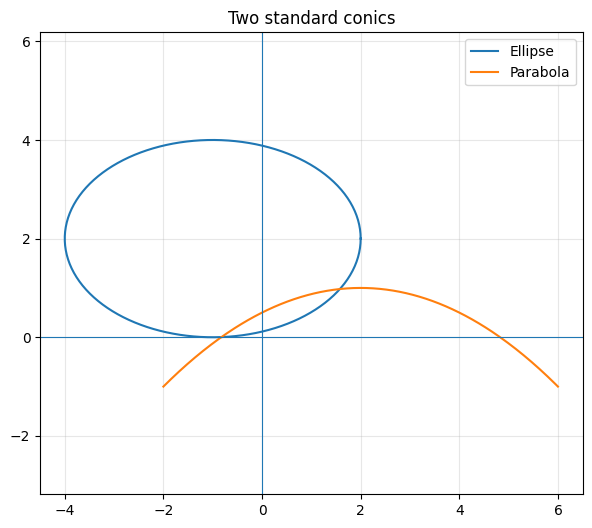

In [81]:
t=np.linspace(0,2*np.pi,400)
xe=-1+3*np.cos(t); ye=2+2*np.sin(t)
yp=1-(np.linspace(-4,4,300)**2)/8
xp=2+np.linspace(-4,4,300)
fig,ax=plt.subplots(figsize=(7,6))
ax.plot(xe,ye,label='Ellipse')
ax.plot(xp,yp,label='Parabola')
ax.axhline(0,linewidth=.8); ax.axvline(0,linewidth=.8); ax.grid(alpha=.3); ax.axis('equal'); ax.legend(); ax.set_title('Two standard conics')
plt.show()

## Optional Preview: Rotation of Axes

Consider

$$
5x^2-6xy+5y^2=20.
$$

The presence of the mixed term $xy$ tells us that the natural axes of the ellipse are not aligned with the original $x$- and $y$-axes.

For this example, use the supplied $45^\circ$ coordinate rotation

$$
x=\frac{x'-y'}{\sqrt2},
$$

and

$$
y=\frac{x'+y'}{\sqrt2}.
$$

Substitute these expressions into the original equation. After simplification, the cross terms cancel and we obtain

$$
2x'^2+8y'^2=20.
$$

Therefore,

$$
\frac{x'^2}{10}+\frac{y'^2}{5/2}=1.
$$

This is an ellipse written in coordinates aligned with its principal axes.

> **Preview:** later in the course, eigenvectors will provide a systematic method for finding these special axis directions. At this point, the goal is simply to see how a coordinate rotation can remove the $xy$ term.

### Classroom Check: Why Can a Rotation Remove the $xy$ Term?

In the example above, what happens to the mixed $x'y'$ terms after we substitute the supplied $45^\circ$ rotation? What does the resulting equation tell us about the new coordinate axes?

In [82]:
reveal_answer_key("concept-4.8-rotation", 'Reveal explanation')

After substituting the supplied $45^\circ$ rotation, the two mixed $x'y'$ contributions cancel. The resulting equation contains only $x'^2$ and $y'^2$, so the new coordinate axes are aligned with the ellipse's principal directions. Later in the course, eigenvectors will give a systematic method for finding such directions.

After substitution: 2*xp**2 + 8*yp**2


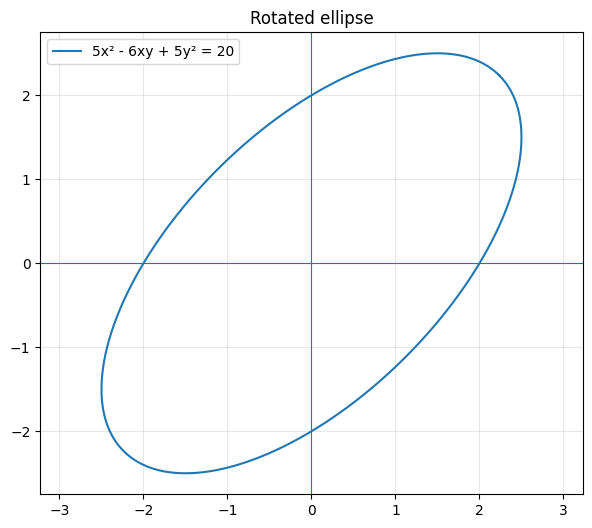

In [83]:
# Verify the supplied 45-degree rotation symbolically and visualize the ellipse.
x_sym, y_sym, xp_sym, yp_sym = sp.symbols('x y xp yp', real=True)
x_rot = (xp_sym - yp_sym) / sp.sqrt(2)
y_rot = (xp_sym + yp_sym) / sp.sqrt(2)
rotated_expression = sp.expand(5*x_rot**2 - 6*x_rot*y_rot + 5*y_rot**2)
print('After substitution:', rotated_expression)

# Plot the rotated ellipse from 2*xp^2 + 8*yp^2 = 20.
t = np.linspace(0, 2*np.pi, 500)
xp = np.sqrt(10) * np.cos(t)
yp = np.sqrt(2.5) * np.sin(t)
R = np.array([
    [1/np.sqrt(2), -1/np.sqrt(2)],
    [1/np.sqrt(2),  1/np.sqrt(2)]
])
xy = R @ np.vstack([xp, yp])
fig, ax = plt.subplots(figsize=(7,6))
ax.plot(xy[0], xy[1], label='5x² - 6xy + 5y² = 20')
ax.axhline(0, linewidth=.8)
ax.axvline(0, linewidth=.8)
ax.grid(alpha=.3)
ax.axis('equal')
ax.legend()
ax.set_title('Rotated ellipse')
plt.show()

In [85]:
# Interactive rotation explorer.
# This cell works both with and without ipywidgets.

import numpy as np
import matplotlib.pyplot as plt

# Try to load interactive widgets.
try:
    from ipywidgets import interact, IntSlider
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False


def rotated_ellipse(theta_degrees=45):
    theta = np.deg2rad(theta_degrees)

    # Parameter values around the ellipse
    t = np.linspace(0, 2*np.pi, 400)

    # Original ellipse:
    # x = 3 cos(t), y = 1.5 sin(t)
    base = np.vstack([
        3*np.cos(t),
        1.5*np.sin(t)
    ])

    # Rotation matrix
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    # Rotate every point of the ellipse
    pts = R @ base

    # Plot
    plt.figure(figsize=(6, 6))
    plt.plot(pts[0], pts[1])
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.grid(alpha=0.3)
    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Rotated ellipse: {theta_degrees} degrees")
    plt.show()


if WIDGETS_AVAILABLE:
    interact(
        rotated_ellipse,
        theta_degrees=IntSlider(
            min=0,
            max=90,
            step=5,
            value=45,
            description="Angle:"
        )
    )
else:
    print("Interactive widgets are unavailable. Showing the 45-degree example.")
    rotated_ellipse(45)

interactive(children=(IntSlider(value=45, description='Angle:', max=90, step=5), Output()), _dom_classes=('wid…

> **Closing note**
>
> Wronskians translate functional independence into a determinant test. Rotation of axes translates a quadratic equation into coordinates aligned with its natural geometry.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Linear differential equation | Differential equation linear in $y$ and its derivatives. |
| Homogeneous | Right-hand side equals zero. |
| Wronskian | Determinant built from functions and derivatives. |
| Conic section | Circle, ellipse, parabola, or hyperbola. |
| Rotation of axes | Orthogonal coordinate change used to remove an $xy$ term. |
| Principal axes | Natural axes aligned with a conic's quadratic form. |

## Section 4.8 Worksheet — In-Class Practice

Work each problem before revealing the instructor solution.

### Problem 1

Verify that $\cos x$ and $\sin x$ solve $y''+y=0$.

In [ ]:
reveal_answer_key("4.8-1", "Reveal Problem 1")

### Problem 2

Compute the Wronskian of $\cos x$ and $\sin x$ and determine whether they are linearly independent.

In [ ]:
reveal_answer_key("4.8-2", "Reveal Problem 2")

### Problem 3

Compute the Wronskian of $1$, $x$, and $x^2$.

In [ ]:
reveal_answer_key("4.8-3", "Reveal Problem 3")

### Problem 4

Identify the center and semiaxes of

$$
\frac{(x-3)^2}{16}+\frac{(y+1)^2}{9}=1.
$$

In [ ]:
reveal_answer_key("4.8-4", "Reveal Problem 4")

### Problem 5

Identify the vertex and opening direction of

$$
(y-2)^2=-12(x+1).
$$

In [ ]:
reveal_answer_key("4.8-5", "Reveal Problem 5")

### Problem 6

Rotate $4x^2+4xy+4y^2=12$ by $45^\circ$ and classify the resulting conic.

In [ ]:
reveal_answer_key("4.8-6", "Reveal Problem 6")